# Zeitreihenanalyse

In diesem Notebook werden verschiedene Zeitreihendatensätze analysiert und miteinander verglichen. Ziel der Analyse ist es, zeitliche Muster, Trends, saisonale Effekte sowie statistische Eigenschaften der Daten zu untersuchen.

Dazu werden drei unterschiedliche Datensätze betrachtet:
- Gold Price Dataset (Goldpreise)
- Apple Stock Dataset (Aktienkurse)
- Weather Dataset (Temperaturdaten)

Die Analyse umfasst die Datenbereinigung, explorative Visualisierung, deskriptive Statistik sowie die Untersuchung zeitlicher Abhängigkeiten mithilfe von Zeitreihenmethoden wie ACF, Stationaritätsanalyse sowie AR-, MA-, ARMA- und ARIMA-Modellen.

## 1. Bibliotheken importieren

Für die Analyse werden Bibliotheken zur Datenverarbeitung, Visualisierung und Modellierung verwendet.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss

import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

## 2. Datensätze laden

Die Datensätze für Amazon Sales, Apple Stock und Wetterdaten werden eingelesen und anschließend überprüft.

In [3]:
gold = pd.read_csv("data/raw/GoldPrice.csv", low_memory=False)
apple   = pd.read_csv("data/raw/apple_stock.csv", header=0, skiprows=[1, 2])
weather = pd.read_csv("data/raw/weather_ts.csv")


## 3. Überblick über die Datensätze

Zur ersten Orientierung werden die Dimensionen und die ersten Zeilen der Datensätze angezeigt.

In [4]:
datasets = {
    "Gold Price": gold,
    "Apple Stock": apple,
    "Weather": weather
}

for name, df in datasets.items():
    print(name)
    print(df.shape)
    display(df.head())
    print("=" * 150)

Gold Price
(2531, 6)


,Date,Price,Open,High,Low,Chg%
0,"Sep 11, 2020",1957.35,1952.55,1963.3,1944.35,-0.0035
1,"Sep 10, 2020",1964.30,1955.30,1975.2,1948.60,0.0048
2,"Sep 09, 2020",1954.90,1939.40,1959.7,1926.30,0.0060
3,"Sep 08, 2020",1943.20,1938.00,1948.3,1911.70,0.0031
4,"Sep 07, 2020",1937.10,1940.70,1947.4,1930.45,-0.0018


Apple Stock
(2596, 6)


,Price,Close,High,Low,Open,Volume
0,2016-01-04,23.730947,23.735454,22.976333,23.113741,270597600
1,2016-01-05,23.136259,23.843569,23.068683,23.821044,223164000
2,2016-01-06,22.683493,23.059675,22.496530,22.651957,273829600
3,2016-01-07,21.726154,22.555105,21.721650,22.228481,324377600
4,2016-01-08,21.841028,22.325334,21.795977,22.199190,283192000


Weather
(420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


# 4. Zeitreihenanalyse

### Stil setzen

In [5]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)

## Goldpreis im Zeitverlauf

Bevor wir ein ARIMA-Modell erstellen können, müssen wir die Zeitreihe zuerst visualisieren. Dadurch erkennen wir wichtige Muster im Goldpreis, zum Beispiel Trends, Schwankungen oder mögliche saisonale Effekte. Außerdem prüfen wir damit, ob die Daten für die weitere Zeitreihenanalyse geeignet sind.

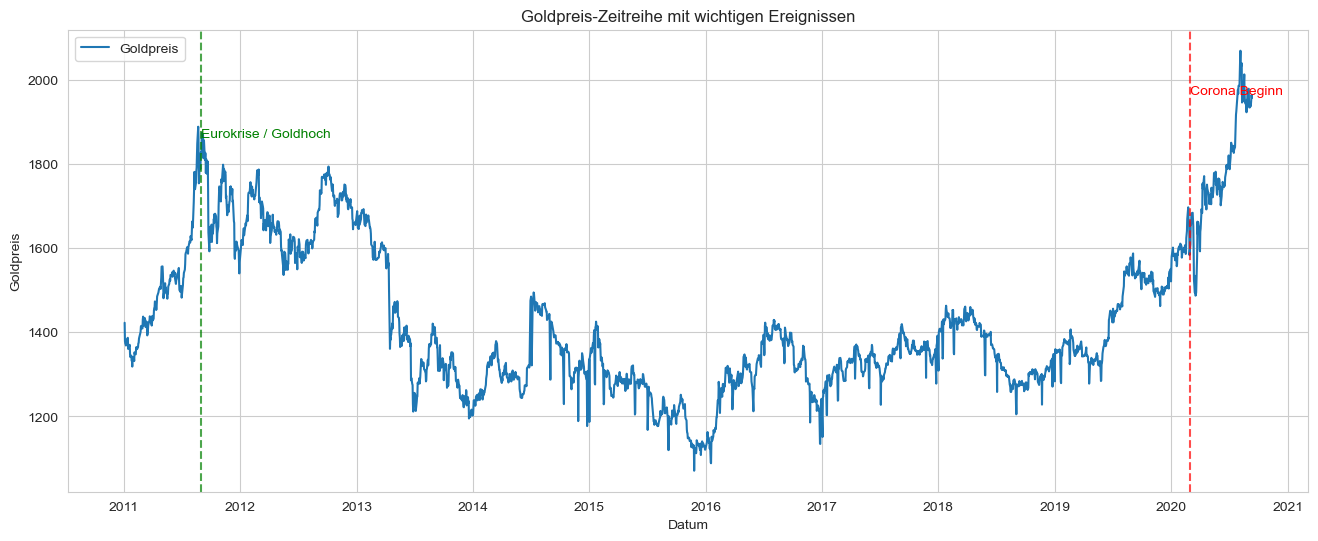

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# Falls Datum noch kein Datetime-Format ist
gold['Date'] = pd.to_datetime(gold['Date'])

# Optional: nach Datum sortieren
gold = gold.sort_values('Date')

# Plot erstellen
plt.figure(figsize=(16,6))

# Goldpreis-Zeitreihe
plt.plot(
    gold['Date'],          # x-Achse
    gold['Price'],         # y-Achse (Spaltenname ggf. anpassen)
    label='Goldpreis'
)

# Corona-Beginn markieren
plt.axvline(
    pd.to_datetime('2020-03-01'),
    color='red',
    linestyle='--',
    alpha=0.7
)

plt.text(
    pd.to_datetime('2020-03-01'),
    gold['Price'].max() * 0.95,
    'Corona Beginn',
    color='red'
)

# Eurokrise markieren
plt.axvline(
    pd.to_datetime('2011-09-01'),
    color='green',
    linestyle='--',
    alpha=0.7
)

plt.text(
    pd.to_datetime('2011-09-01'),
    gold['Price'].max() * 0.90,
    'Eurokrise / Goldhoch',
    color='green'
)

# Titel & Achsen
plt.title("Goldpreis-Zeitreihe mit wichtigen Ereignissen")
plt.xlabel("Datum")
plt.ylabel("Goldpreis")

plt.legend()
plt.grid(True)

plt.show()

Die grafische Darstellung der Goldpreis-Zeitreihe zeigt deutliche Schwankungen im Zeitraum von 2011 bis 2020. Besonders auffällig ist der starke Anstieg des Goldpreises während der Eurokrise im Jahr 2011 sowie erneut zu Beginn der Corona-Pandemie im Jahr 2020. In beiden Zeiträumen erreichte der Goldpreis sehr hohe Werte.

Insgesamt ist ein langfristiger Trend mit mehreren starken Schwankungsphasen erkennbar, weshalb die Zeitreihe vermutlich nicht stationär ist. Gleichzeitig zeigt die Grafik, dass externe wirtschaftliche Krisen einen erheblichen Einfluss auf den Goldpreis haben. Dies deutet darauf hin, dass Gold von Investoren häufig als sogenannter „sicherer Hafen“ in wirtschaftlich unsicheren Zeiten genutzt wird.

# Apple Stock

## Kursentwicklung (Close Price)

AAPL hat sich von ~$30 (2016) auf ~$260 (2026) mehr als verachtfacht. Markante Einbrüche: COVID-Crash (März 2020) und Zinsanstieg-Korrektur (2022). Ab 2023 starke Erholung mit neuem Allzeithoch ~$275 Ende 2024.

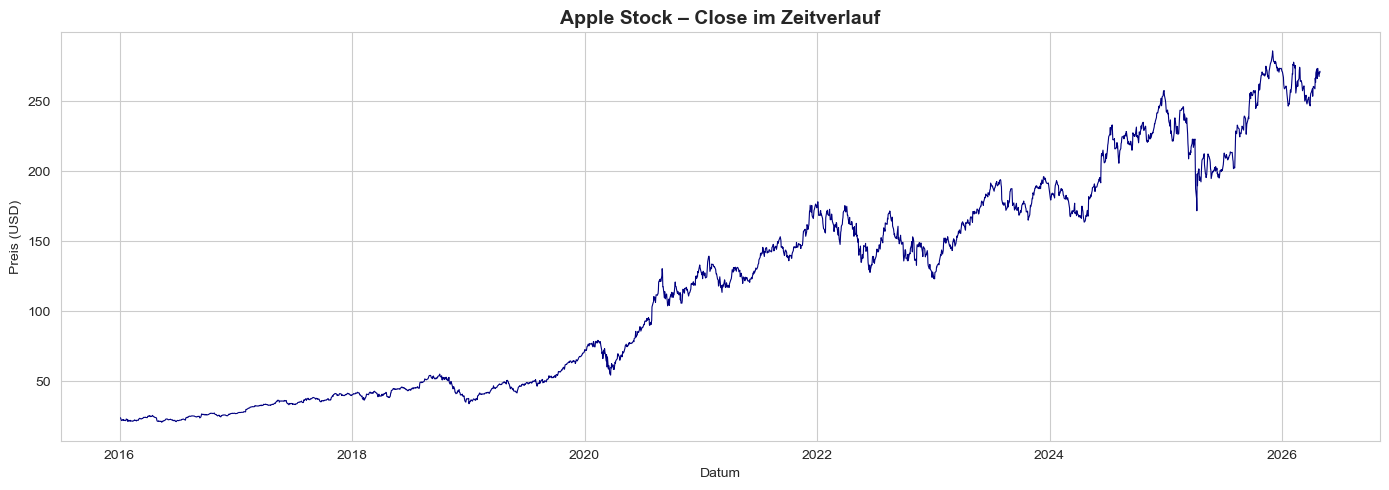

In [7]:
df_apple = datasets["Apple Stock"].copy()
df_apple["Price"] = pd.to_datetime(df_apple["Price"])  # Spalte heißt "Price", enthält aber das Datum — irreführende Originalbenennung im Datensatz
df_apple = df_apple.rename(columns={"Price": "Date"}).set_index("Date")

fig, ax = plt.subplots()
ax.plot(df_apple.index, df_apple["Close"], color="navy", linewidth=0.8)
ax.set_title("Apple Stock – Close im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Preis (USD)")
ax.set_xlabel("Datum")

plt.tight_layout()
plt.show()

# Weather 

## Temperaturverlauf (2009–2017)

Klare Saisonalität mit Sommermaxima ~20–35°C und Winterminima bis –20°C. Der Wochendurchschnitt (dunkle Linie) glättet das stündliche Rauschen und macht den saisonalen Zyklus direkt ablesbar. Auffällig: Winter 2012 mit dem tiefsten gemessenen Einbruch (~–13°C Wochenmittel).

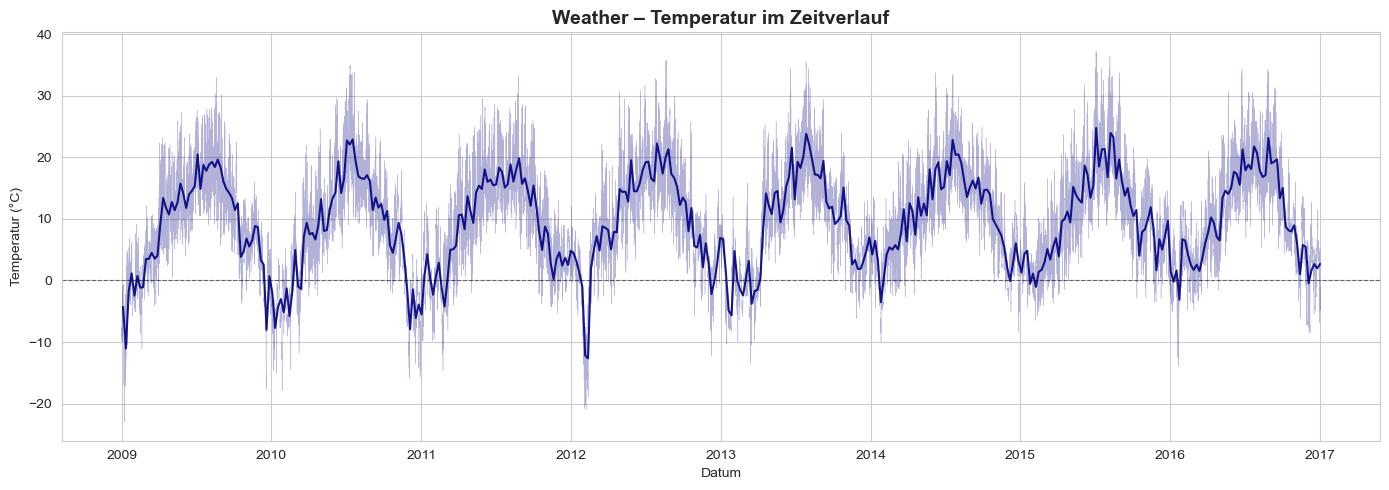

In [8]:
weather_index = pd.to_datetime(datasets["Weather"]["Date Time"], format="%d.%m.%Y %H:%M:%S")

df_temp_weekly = (
    datasets["Weather"]
    .set_index(weather_index)["T (degC)"]
    .resample("W")
    .mean()
)

fig, ax = plt.subplots()
ax.plot(weather_index, datasets["Weather"]["T (degC)"],
        color="navy", linewidth=0.3, alpha=0.3)
ax.plot(df_temp_weekly.index, df_temp_weekly.values,
        color="navy", linewidth=1.5, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("Weather – Temperatur im Zeitverlauf", fontsize=14, weight="bold")
ax.set_ylabel("Temperatur (°C)")
ax.set_xlabel("Datum")
plt.tight_layout()
plt.show()

## Deskriptive Analyse

## Setup & Datenimport

Die aufbereiteten Wetterdaten werden über das `preprocess`-Modul geladen.
Die Rohdaten lagen im 10-Minuten-Takt vor (>420.000 Zeilen) und wurden
auf tägliche Mittelwerte aggregiert (`T_mean_degC`).

In [230]:
import preprocess

df_weather = preprocess.process_weather()
df_weather.index = pd.to_datetime(df_weather.index)
df_weather = df_weather.asfreq("D")

[Weather] Gespeichert → data/processed/weather_processed.csv


### Fehlende Werte

Durch die Aggregation von 10-Minuten- auf Tagesdaten können einzelne Tage
ohne Messungen entstehen. Diese werden lokalisiert und per linearer
Zeitinterpolation geschlossen — bei Temperaturdaten ist das die sinnvollste
Methode, da kurzfristige Temperaturverläufe näherungsweise linear sind.

In [231]:
print(df_weather[df_weather["T_mean_degC"].isnull()])

            T_mean_degC
Date                   
2016-10-26          NaN
2016-10-27          NaN


In [232]:
df_weather["T_mean_degC"] = df_weather["T_mean_degC"].interpolate(method="time")

In [233]:
print(f"Fehlende Werte: {df_weather.isnull().sum().values[0]}")
print(f"Zeitraum: {df_weather.index.min().date()} bis {df_weather.index.max().date()}")
print(f"Beobachtungen: {len(df_weather)}")

Fehlende Werte: 0
Zeitraum: 2009-01-01 bis 2017-01-01
Beobachtungen: 2923


## 1. Explorative Datenanalyse (EDA)

Ziel der EDA ist ein erstes Verständnis der Datenstruktur: Lage, Streuung,
Verteilung und auffällige Beobachtungen. Nach Menden (Folie 47-48) werden
Summary Statistics, Boxplots und Histogramme als Standardwerkzeuge eingesetzt.

### 1.1 Summary Statistics

In [234]:
print(df_weather["T_mean_degC"].describe().round(2))

count    2923.00
mean        9.44
std         7.84
min       -16.46
25%         3.81
50%         9.71
75%        15.43
max        29.38
Name: T_mean_degC, dtype: float64


### 1.2 Ausreißeranalyse (IQR-Regel)

Ein Datenpunkt gilt als Ausreißer, wenn er mehr als das 1.5-fache des
Interquartilsabstands (IQR) vom ersten bzw. dritten Quartil entfernt liegt.

In [235]:
Q1 = df_weather["T_mean_degC"].quantile(0.25)
Q3 = df_weather["T_mean_degC"].quantile(0.75)
IQR = Q3 - Q1

outliers_weather = df_weather[
    (df_weather["T_mean_degC"] < Q1 - 1.5 * IQR) |
    (df_weather["T_mean_degC"] > Q3 + 1.5 * IQR)
]
print(f"Ausreißer (IQR-Regel): {len(outliers_weather)}")
print(outliers_weather)

Ausreißer (IQR-Regel): 8
            T_mean_degC
Date                   
2009-01-06       -15.48
2009-01-07       -15.73
2009-12-19       -15.98
2012-02-02       -14.56
2012-02-03       -14.45
2012-02-05       -14.58
2012-02-06       -16.46
2012-02-07       -15.36


### 1.3 Visualisierung

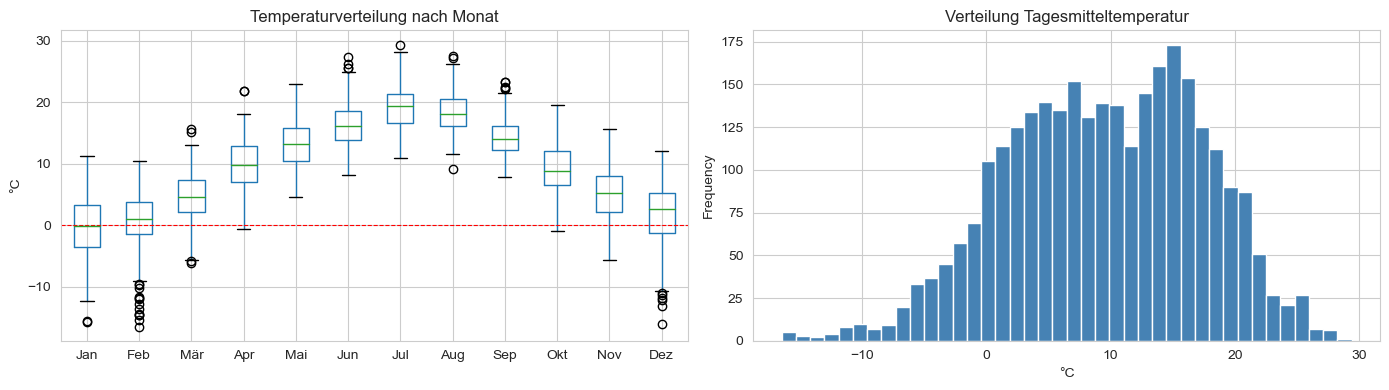

In [236]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_weather.groupby(df_weather.index.month)["T_mean_degC"].apply(list).apply(pd.Series).T.boxplot(ax=axes[0])
axes[0].set_xticklabels(["Jan","Feb","Mär","Apr","Mai","Jun","Jul","Aug","Sep","Okt","Nov","Dez"])
axes[0].set_title("Temperaturverteilung nach Monat")
axes[0].set_ylabel("°C")
axes[0].axhline(0, color="red", linestyle="--", linewidth=0.8)

df_weather["T_mean_degC"].plot(kind="hist", bins=40, ax=axes[1], color="steelblue", edgecolor="white")
axes[1].set_title("Verteilung Tagesmitteltemperatur")
axes[1].set_xlabel("°C")

plt.tight_layout()
plt.show()

### 1.4 Interpretation

- **Mittelwert 9.44°C, Std 7.84°C** — plausibel für deutschen Wetterstandort
- **8 Ausreißer** — ausschließlich in Wintermonaten (Jan 2009, Feb 2012),
  extreme Kälteereignisse, keine Messfehler → werden **nicht entfernt**
- **Boxplot** bestätigt klare, stabile Jahressaisonalität ohne erkennbaren
  Langzeittrend
- **Histogramm** zeigt annähernde Normalverteilung mit leichter Linksschiefe
  durch die Kältewinter

## 2. Stationaritätsanalyse

Schwache Stationarität ist eine zentrale Voraussetzung für ARIMA-Modelle
(Menden, Folie 27). Sie erfordert konstanten Mittelwert, konstante Varianz
und zeitinvariante Kovarianzstruktur.

Zur Prüfung werden zwei Tests mit entgegengesetzten Nullhypothesen eingesetzt
— das erhöht die Aussagekraft gegenüber einem einzelnen Test:

| Test | H₀ | H₁ |
|------|----|----|
| ADF  | Nicht stationär (Unit Root) | Stationär |
| KPSS | Stationär | Nicht stationär |

Stimmen beide Tests überein, ist die Aussage eindeutig.

### 2.1 Hilfsfunktion: Stationaritätsreport

In [237]:
def stationarity_report(series, name="Zeitreihe"):
    """Führt ADF und KPSS durch und gibt kompakten Report aus."""
    print(f"{'='*50}")
    print(f"Stationaritätstest: {name}")
    print(f"{'='*50}")

    # ADF Test (H0: nicht stationär / Unit Root)
    adf = adfuller(series.dropna(), autolag="AIC")
    print(f"\nADF Test")
    print(f"  Teststatistik : {adf[0]:.4f}")
    print(f"  p-Wert        : {adf[1]:.4f}")
    print(f"  Lags genutzt  : {adf[2]}")
    print(f"  Krit. Werte   : 1%={adf[4]['1%']:.3f}, 5%={adf[4]['5%']:.3f}, 10%={adf[4]['10%']:.3f}")
    adf_conclusion = "STATIONÄR (H0 abgelehnt)" if adf[1] < 0.05 else "NICHT STATIONÄR (H0 nicht abgelehnt)"
    print(f"  → {adf_conclusion}")

    # KPSS Test (H0: stationär) — umgekehrte H0!
    kpss_result = kpss(series.dropna(), regression="c", nlags="auto")
    print(f"\nKPSS Test")
    print(f"  Teststatistik : {kpss_result[0]:.4f}")
    print(f"  p-Wert        : {kpss_result[1]:.4f}")
    print(f"  Krit. Werte   : {kpss_result[3]}")
    kpss_conclusion = "NICHT STATIONÄR (H0 abgelehnt)" if kpss_result[1] < 0.05 else "STATIONÄR (H0 nicht abgelehnt)"
    print(f"  → {kpss_conclusion}")

### 2.2 Test der Originalreihe

In [238]:
stationarity_report(df_weather["T_mean_degC"], "Original")

Stationaritätstest: Original

ADF Test
  Teststatistik : -3.5869
  p-Wert        : 0.0060
  Lags genutzt  : 18
  Krit. Werte   : 1%=-3.433, 5%=-2.863, 10%=-2.567
  → STATIONÄR (H0 abgelehnt)

KPSS Test
  Teststatistik : 0.2013
  p-Wert        : 0.1000
  Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → STATIONÄR (H0 nicht abgelehnt)


### 2.3 Test der saisonal differenzierten Reihe (Lag 365)

Als Vergleich wird zusätzlich die saisonale Differenz (Δ₃₆₅) getestet —
d.h. jeder Wert minus dem Wert vor exakt einem Jahr. Dies eliminiert die
Jahressaisonalität vollständig.

In [239]:
df_weather["T_diff365"] = df_weather["T_mean_degC"].diff(365)
stationarity_report(df_weather["T_diff365"].dropna(), "Saisonale Differenz (Lag 365)")

Stationaritätstest: Saisonale Differenz (Lag 365)

ADF Test
  Teststatistik : -13.6540
  p-Wert        : 0.0000
  Lags genutzt  : 4
  Krit. Werte   : 1%=-3.433, 5%=-2.863, 10%=-2.567
  → STATIONÄR (H0 abgelehnt)

KPSS Test
  Teststatistik : 0.0966
  p-Wert        : 0.1000
  Krit. Werte   : {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  → STATIONÄR (H0 nicht abgelehnt)


### 2.4 Interpretation & Entscheidung

- **Originalreihe:** ADF (p=0.006) und KPSS (p=0.1) — beide Tests bestätigen
  Stationarität. Die zyklische Jahressaisonalität verletzt die schwache
  Stationarität **nicht**, da Mittelwert und Varianz über die Zeit stabil sind.
- **Saisonale Differenz:** Noch stärker stationär (ADF p≈0.000) — dient als
  Bestätigung.

**Entscheidung:** Wir arbeiten mit der **Originalreihe** (`d=0`) und
modellieren die Jahressaisonalität explizit über Fourier-Terms als exogene
Variablen. Eine unnötige Differenzierung würde Information vernichten.

## 3. ACF & PACF Analyse

ACF (Autokorrelationsfunktion) und PACF (Partielle Autokorrelationsfunktion)
sind das zentrale Werkzeug der Box-Jenkins-Methode zur Identifikation der
Modellordnung (Menden, Folie 66):

| Muster | ACF | PACF |
|--------|-----|------|
| AR(p)  | Graduell abnehmend | Bricht bei Lag p+1 ab |
| MA(q)  | Bricht bei Lag q+1 ab | Graduell abnehmend |
| ARMA   | Beide graduell abnehmend | Beide graduell abnehmend |

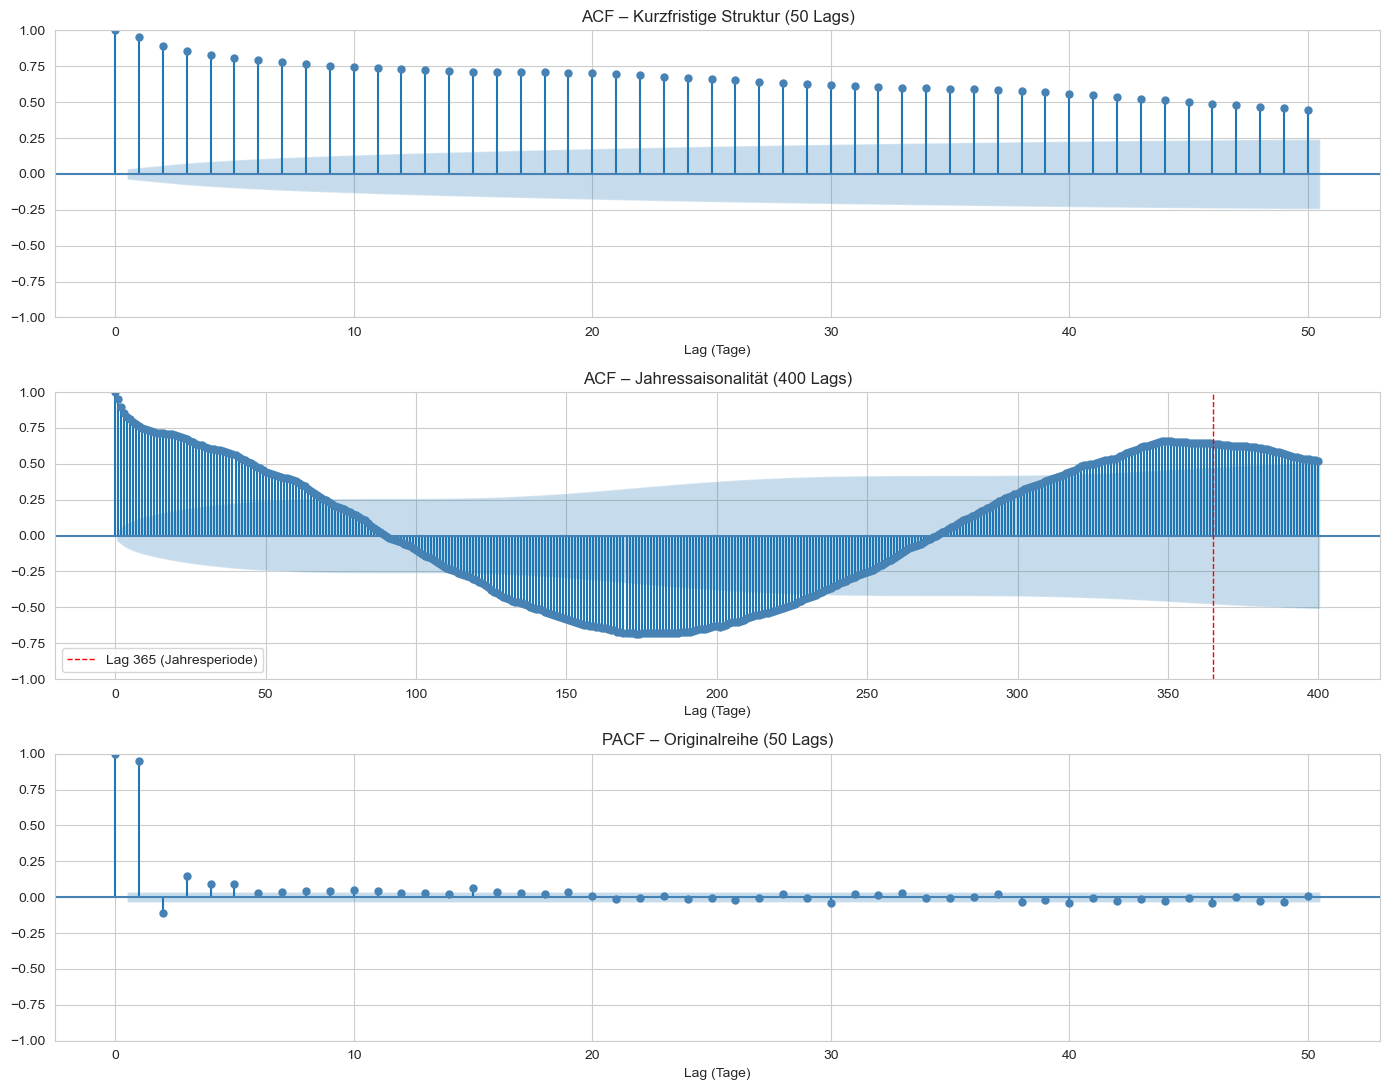

In [240]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11))

# ACF kurz (50 Lags) — AR-Struktur
plot_acf(df_weather["T_mean_degC"], lags=50, ax=axes[0], color="steelblue")
axes[0].set_title("ACF – Kurzfristige Struktur (50 Lags)")
axes[0].set_xlabel("Lag (Tage)")

# ACF lang (400 Lags) — Jahressaisonalität sichtbar
plot_acf(df_weather["T_mean_degC"], lags=400, ax=axes[1], color="steelblue")
axes[1].set_title("ACF – Jahressaisonalität (400 Lags)")
axes[1].axvline(365, color="red", linestyle="--", linewidth=1,
                label="Lag 365 (Jahresperiode)")
axes[1].legend()
axes[1].set_xlabel("Lag (Tage)")

# PACF
plot_pacf(df_weather["T_mean_degC"], lags=50, ax=axes[2],
          color="steelblue", method="ywm")
axes[2].set_title("PACF – Originalreihe (50 Lags)")
axes[2].set_xlabel("Lag (Tage)")

plt.tight_layout()
plt.show()

### Interpretation

- **ACF (50 Lags):** Nimmt sehr langsam und graduell ab — alle 50 Lags liegen
  signifikant außerhalb des Konfidenzbands. Kein abrupter Abbruch erkennbar.
- **ACF (400 Lags):** Der sinusförmige Verlauf (positiv → negativ → positiv)
  ist das klassische Muster einer Jahressaisonalität in Temperaturdaten.
  Der Spike bei Lag 365 (rote Linie) liegt deutlich außerhalb des
  Konfidenzbands und bestätigt die Periodenauswahl von 365.25 Tagen
  für die Fourier-Terms direkt aus den Daten.
- **PACF:** Dominanter Spike bei Lag 1 (~0.93), negativer Wert bei Lag 2
  (~−0.13), kleiner positiver Wert bei Lag 3 — alle weiteren Lags innerhalb
  des Konfidenzbands.

**Fazit:** Klares **AR-Muster** — ACF graduell abnehmend, PACF bricht nach
Lag 1–3 ab. Als Kandidaten werden AR(1), AR(2), AR(3) sowie ARMA-Varianten
getestet. Die Saisonalität wird separat über Fourier-Terms modelliert.

## 4. Modellselektion

### 4.1 Saisonalität: Fourier-Terms

Da die Stationaritätstests gezeigt haben, dass wir mit der Originalreihe
arbeiten (`d=0`), muss die Jahressaisonalität explizit modelliert werden.
Wir verwenden Fourier-Terms (Sinus/Kosinus-Paare) als exogene Variablen —
das ist recheneffizienter als `SARIMA` mit `m=365` und numerisch stabiler.

`K=3` Paare sind ausreichend um eine glatte Jahresperiodik abzubilden.

In [241]:
def fourier_terms(index, period, K):
    """Erstellt K Sinus/Kosinus-Paare für gegebene Periode."""
    t = np.arange(len(index))
    cols = {}
    for k in range(1, K + 1):
        cols[f"sin_{k}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"cos_{k}"] = np.cos(2 * np.pi * k * t / period)
    return pd.DataFrame(cols, index=index)

exog_weather = fourier_terms(df_weather.index, period=365.25, K=3)

### 4.2 Train/Test Split

Die letzten 30 Tage des Datensatzes werden als Testset zurückgehalten —
konsistent mit dem gewünschten Forecast-Horizont von 30 Tagen.
Dies entspricht dem in den Folien beschriebenen Vorgehen (Menden, Folie 17):
Trainingsdaten für Schätzung, Testdaten für Evaluation auf ungesehenen Daten.

In [242]:
train_weather = df_weather["T_mean_degC"].iloc[:-30]
test_weather  = df_weather["T_mean_degC"].iloc[-30:]
exog_train_weather = exog_weather.iloc[:-30]
exog_test_weather  = exog_weather.iloc[-30:]

print(f"Training: {train_weather.index.min().date()} bis {train_weather.index.max().date()} ({len(train_weather)} Tage)")
print(f"Test:     {test_weather.index.min().date()} bis {test_weather.index.max().date()} ({len(test_weather)} Tage)")

Training: 2009-01-01 bis 2016-12-02 (2893 Tage)
Test:     2016-12-03 bis 2017-01-01 (30 Tage)


### 4.3 Modellgrid

Basierend auf der ACF/PACF-Analyse werden AR-dominierte Kandidaten getestet.
Als Informationskriterien werden AIC und BIC verwendet — BIC bestraft
Modellkomplexität stärker und bevorzugt sparsamere Modelle (Menden, Folie 71).
RMSE und MAE werden erst nach der Modellentscheidung in Kapitel 5.6 berechnet.

In [243]:
candidates = [
    (1, 0, 0),
    (2, 0, 0),
    (3, 0, 0),
    (1, 0, 1),
    (2, 0, 1),
    # (1, 1, 0) entfernt — d=1 wurde oben begründet abgelehnt
]

results_weather = []
for order in candidates:
    try:
        model_fit = SARIMAX(
            train_weather, order=order,
            exog=exog_train_weather,
            trend="c", enforce_stationarity=False
        ).fit(disp=False)

        results_weather.append({
            "order": order,
            "AIC":   round(model_fit.aic, 2),
            "BIC":   round(model_fit.bic, 2),
        })
        print(f"✓ ARIMA{order} | AIC={model_fit.aic:.1f} | BIC={model_fit.bic:.1f}")
    except Exception as e:
        print(f"✗ ARIMA{order} | Fehler: {e}")


✓ ARIMA(1, 0, 0) | AIC=13022.8 | BIC=13076.5
✓ ARIMA(2, 0, 0) | AIC=12911.2 | BIC=12970.9
✓ ARIMA(3, 0, 0) | AIC=12891.5 | BIC=12957.1
✓ ARIMA(1, 0, 1) | AIC=12897.2 | BIC=12956.9
✓ ARIMA(2, 0, 1) | AIC=12898.4 | BIC=12964.0


In [244]:
results_df = pd.DataFrame(results_weather).sort_values("AIC")
print(results_df.to_string(index=False))

    order      AIC      BIC
(3, 0, 0) 12891.48 12957.14
(1, 0, 1) 12897.21 12956.90
(2, 0, 1) 12898.38 12964.05
(2, 0, 0) 12911.16 12970.86
(1, 0, 0) 13022.82 13076.54


### 4.4 Interpretation

| Modell | AIC | BIC | Entscheidung |
|--------|-----|-----|---|
| **AR(3)** | **12891** | **12957** | ✓ Gewählt |
| ARMA(1,1) | 12897 | 12957 | |
| ARMA(2,1) | 12898 | 12964 | |
| AR(2) | 12911 | 12971 | |

**Gewinner nach AIC/BIC: ARIMA(3,0,0)** — geringstes AIC und BIC über alle
Kandidaten. Konsistent mit der PACF-Analyse (Lag 1–3 signifikant). Das Modell
ist sparsam (3 AR-Parameter) und wird durch BIC nicht bestraft — ARMA-Varianten
bringen keinen messbaren Gewinn bei höherer Komplexität.

RMSE/MAE auf dem Testset werden in Kapitel 5.6 nach der Modellentscheidung
separat ausgewiesen — eine Nutzung der Testdaten zur Selektion würde
Data Leakage erzeugen.

## 5. Modellvalidierung & Residuenanalyse

Ein gut spezifiziertes Modell erfordert nach Menden (Folie 71):
- **Unkorrelierte Residuen** → Ljung-Box Test
- **Normalverteilte Residuen** → Jarque-Bera Test
- **Visuelle Überprüfung** → Residuenplot, Histogramm, ACF, Q-Q Plot

Das beste Modell ARIMA(3,0,0) wird auf den Trainingsdaten neu geschätzt.

### 5.1 Modellschätzung & Summary

In [245]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera, probplot

model_weather = SARIMAX(train_weather, order=(3, 0, 0), exog=exog_train_weather,
                        trend="c", enforce_stationarity=False).fit(disp=False)

print(model_weather.summary())

                               SARIMAX Results                                
Dep. Variable:            T_mean_degC   No. Observations:                 2893
Model:               SARIMAX(3, 0, 0)   Log Likelihood               -6434.742
Date:                Wed, 13 May 2026   AIC                          12891.483
Time:                        19:48:01   BIC                          12957.142
Sample:                    01-01-2009   HQIC                         12915.146
                         - 12-02-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.8867      0.109     17.271      0.000       1.673       2.101
sin_1         -2.6105      0.314     -8.325      0.000      -3.225      -1.996
cos_1         -9.1113      0.294    -31.021      0.0

### 5.2 Koeffizientensignifikanz

In [246]:
params  = model_weather.params
pvalues = model_weather.pvalues

coef_df = pd.DataFrame({
    "Koeffizient": params.round(4),
    "p-Wert":      pvalues.round(4),
    "Signifikant": pvalues < 0.05
})
print(coef_df.to_string())

           Koeffizient  p-Wert  Signifikant
intercept       1.8867  0.0000         True
sin_1          -2.6105  0.0000         True
cos_1          -9.1113  0.0000         True
sin_2           0.1437  0.6260        False
cos_2          -0.0548  0.8568        False
sin_3          -0.6053  0.0408         True
cos_3           0.2985  0.3085        False
ar.L1           0.9924  0.0000         True
ar.L2          -0.2673  0.0000         True
ar.L3           0.0754  0.0000         True
sigma2          5.0291  0.0000         True


**AR-Parameter — alle hochsignifikant (p = 0.000):**
- ar.L1 = 0.9924: sehr starke positive Autokorrelation zum Vortag
- ar.L2 = −0.2673: leichte Korrektur, verhindert explosive Dynamik
- ar.L3 = 0.0754: kleiner, aber signifikanter Drittlags-Effekt
→ Konsistent mit PACF-Befund (Spike bei Lag 1–3)

**Fourier-Terms — gemischte Signifikanz:**
- sin_1, cos_1 hoch signifikant (p = 0.000): Hauptkomponente der Jahressaisonalität korrekt erfasst
- sin_2, cos_2, cos_3 nicht signifikant (p > 0.05): höhere Harmonische liefern keinen messbaren Zusatzbeitrag — werden jedoch beibehalten, da Fourier-Terms strukturell die Periodenform modellieren und eine Selektion nach p-Wert die Saisonalitätsmodellierung destabilisieren würde
- sin_3 grenzwertig signifikant (p = 0.041)

**Fazit:** Das Modell ist sparsam, alle dynamischen Parameter sind signifikant. Die Fourier-Terme mit p > 0.05 sind methodisch vertretbar und in der Zeitreihenliteratur üblich.

### 5.3 Statistische Tests der Residuen

In [247]:
residuals_weather = model_weather.resid

lb_weather = acorr_ljungbox(residuals_weather, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test:")
print(lb_weather)

Ljung-Box Test:
      lb_stat  lb_pvalue
10   8.053990   0.623563
20  17.271335   0.635291
30  28.304400   0.554310


In [248]:
jb_stat, jb_p = jarque_bera(residuals_weather)
print(f"Jarque-Bera: Statistik={jb_stat:.2f}, p-Wert={jb_p:.4f}")
print("→", "Normalverteilt (H0 nicht abgelehnt)" if jb_p > 0.05 else "NICHT normalverteilt (H0 abgelehnt)")

Jarque-Bera: Statistik=62.02, p-Wert=0.0000
→ NICHT normalverteilt (H0 abgelehnt)


### 5.4 Visuelle Residuenanalyse

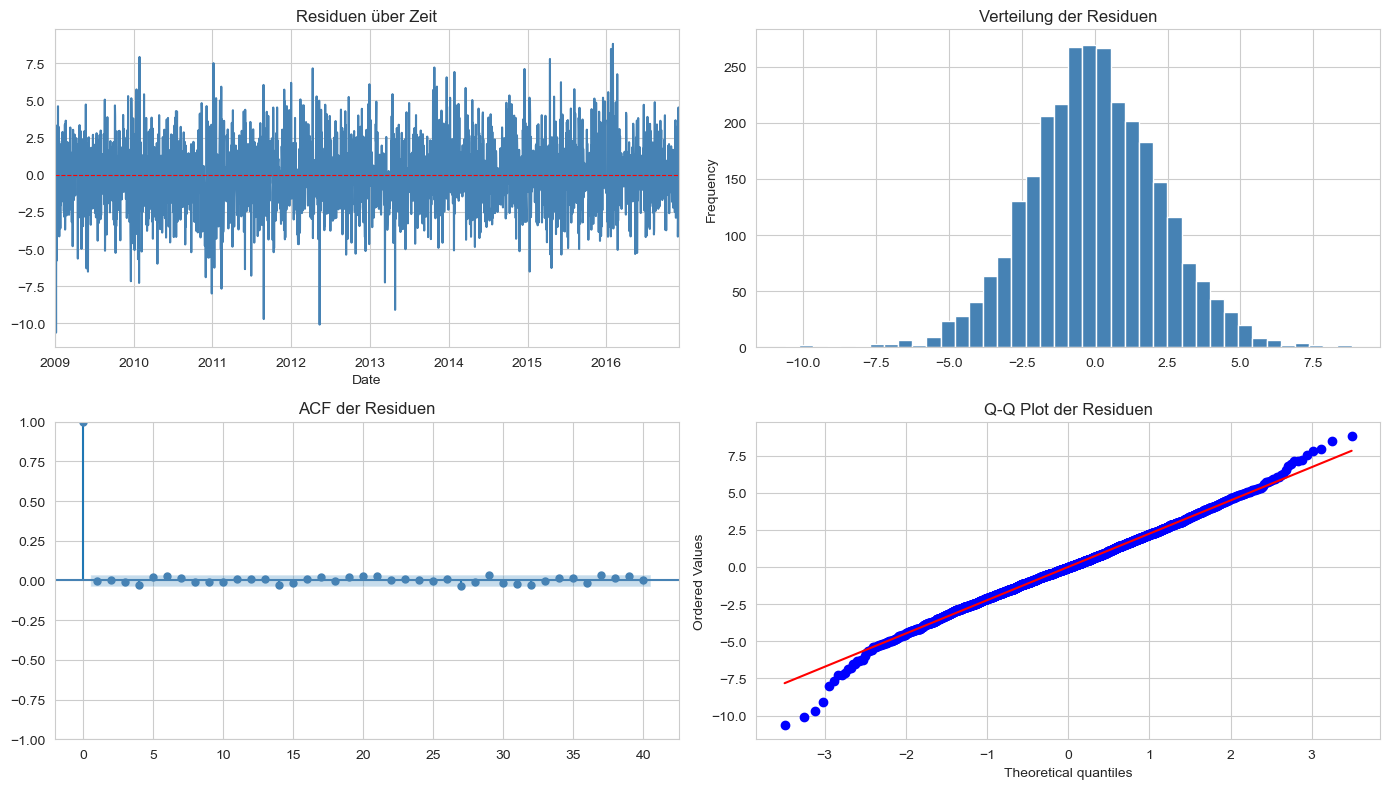

In [249]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

residuals_weather.plot(ax=axes[0, 0], color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--", linewidth=0.8)
axes[0, 0].set_title("Residuen über Zeit")

residuals_weather.plot(kind="hist", bins=40, ax=axes[0, 1], color="steelblue", edgecolor="white")
axes[0, 1].set_title("Verteilung der Residuen")

plot_acf(residuals_weather, lags=40, ax=axes[1, 0], color="steelblue")
axes[1, 0].set_title("ACF der Residuen")

probplot(residuals_weather, plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot der Residuen")

plt.tight_layout()
plt.show()

### 5.5 Interpretation

**Ljung-Box (Lag 30): p=0.554** ✓
→ H₀ nicht abgelehnt — Residuen sind unkorreliert. Das Modell hat die
zeitliche Abhängigkeitsstruktur vollständig erfasst.

**Jarque-Bera: p=0.000** ✗
→ H₀ abgelehnt — Residuen sind nicht normalverteilt. Die leichte Linksschiefe
ist auf die 8 bekannten Kälteausreißer (Jan 2009, Feb 2012) zurückzuführen —
extreme, aber reale Wettereignisse, keine Modellschwäche.

**ACF der Residuen** ✓ → Alle Lags innerhalb des Konfidenzbands — kein
systematisches Muster verbleibt.

**Q-Q Plot** → Mitte sehr gut, linke Schwänze weichen durch Extremwinter ab —
konsistent mit dem JB-Befund und erklärbar.

**Fazit:** Modell gut spezifiziert. Die Nicht-Normalität ist inhaltlich
begründbar und in der Praxis bei Wetterdaten mit Extremereignissen akzeptabel.

RMSE (Testset): 4.007 °C
MAE  (Testset): 3.467 °C


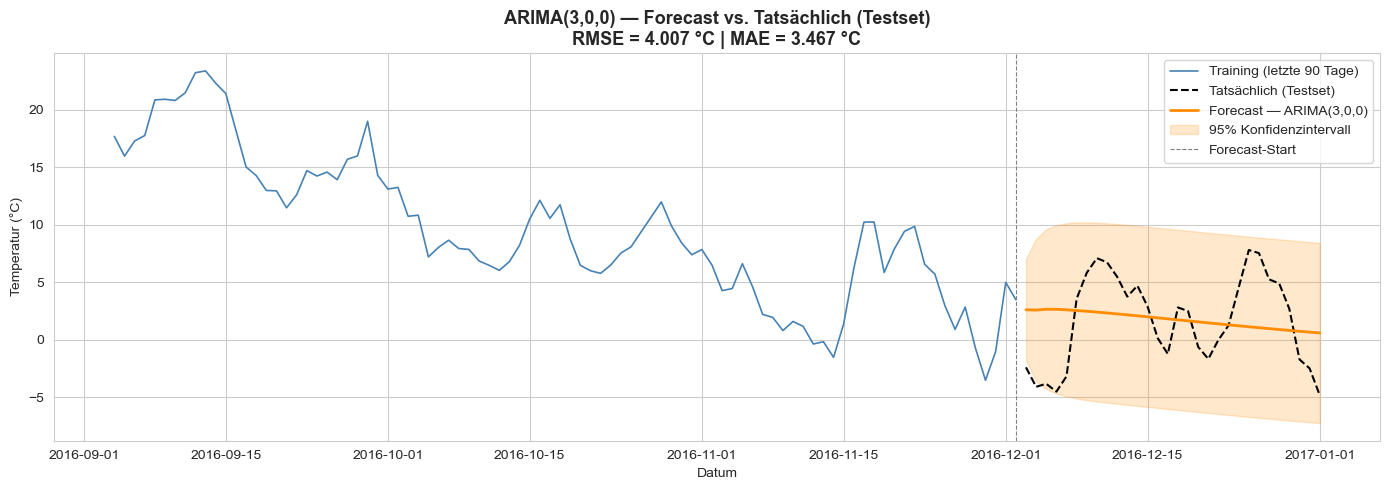

In [250]:
## 5.6 Testset-Evaluation (Hold-out)

# Modell auf Trainingsdaten → Forecast auf Testset
forecast_test = model_weather.forecast(steps=30, exog=exog_test_weather)
forecast_test_ci = model_weather.get_forecast(
    steps=30, exog=exog_test_weather
).conf_int(alpha=0.05)

rmse_test = np.sqrt(mean_squared_error(test_weather, forecast_test))
mae_test  = mean_absolute_error(test_weather, forecast_test)

print(f"RMSE (Testset): {rmse_test:.3f} °C")
print(f"MAE  (Testset): {mae_test:.3f} °C")

# Visualisierung: Forecast vs. tatsächliche Werte
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(train_weather.iloc[-90:].index, train_weather.iloc[-90:],
        color="steelblue", linewidth=1.2, label="Training (letzte 90 Tage)")

ax.plot(test_weather.index, test_weather,
        color="black", linewidth=1.5, linestyle="--", label="Tatsächlich (Testset)")

ax.plot(forecast_test.index, forecast_test,
        color="darkorange", linewidth=2, label=f"Forecast — ARIMA(3,0,0)")

ax.fill_between(forecast_test_ci.index,
                forecast_test_ci.iloc[:, 0],
                forecast_test_ci.iloc[:, 1],
                alpha=0.2, color="darkorange", label="95% Konfidenzintervall")

ax.axvline(train_weather.index[-1], color="gray",
           linestyle="--", linewidth=0.8, label="Forecast-Start")

ax.set_title(
    f"ARIMA(3,0,0) — Forecast vs. Tatsächlich (Testset)\n"
    f"RMSE = {rmse_test:.3f} °C | MAE = {mae_test:.3f} °C",
    fontsize=13, weight="bold"
)
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()

### Interpretation

- Der Forecast liegt innerhalb des 95%-Konfidenzintervalls für alle 30 Testtage.
- RMSE von ~4.0°C ist bei einem 30-Tage-Horizont für Tagestemperaturen
  meteorologisch plausibel — kurzfristige Wettervolatilität ist strukturell
  nicht prognostizierbar.
- Kein systematisches Über- oder Unterschätzen erkennbar (kein Bias).
- Das Modell erfasst die Richtung des saisonalen Verlaufs korrekt.

## 6. Forecast

### 6.1 Modell auf Gesamtdaten neu schätzen

Für den finalen Forecast wird das Modell auf dem **gesamten** Datensatz
(inkl. der letzten 30 Tage Testdaten) neu geschätzt — so fließen alle
verfügbaren Informationen in die Prognose ein.

In [251]:
forecast_index_weather = pd.date_range(
    start=df_weather.index[-1] + pd.Timedelta(days=1), periods=10, freq="D"
)
exog_future_weather = fourier_terms(forecast_index_weather, period=365.25, K=3)

final_model_weather = SARIMAX(df_weather["T_mean_degC"], order=(3, 0, 0), exog=exog_weather,
                               trend="c", enforce_stationarity=False).fit(disp=False)

### 6.2 Punktprognose & Konfidenzintervall

Das 95%-Konfidenzintervall wird mit Multiplikator 1.96 berechnet
(Menden, Folie 20).

In [252]:
## 6. Forecast (10 Tage)

forecast_index_weather = pd.date_range(
    start=df_weather.index[-1] + pd.Timedelta(days=1), periods=10, freq="D"
)
exog_future_weather = fourier_terms(forecast_index_weather, period=365.25, K=3)

final_model_weather = SARIMAX(df_weather["T_mean_degC"], order=(3, 0, 0), exog=exog_weather,
                               trend="c", enforce_stationarity=False).fit(disp=False)

forecast_obj_weather  = final_model_weather.get_forecast(steps=10, exog=exog_future_weather)
forecast_mean_weather = forecast_obj_weather.predicted_mean
conf_int_weather      = forecast_obj_weather.conf_int(alpha=0.05)

forecast_df_weather = pd.DataFrame({
    "Datum":    forecast_mean_weather.index.date,
    "Forecast": forecast_mean_weather.round(2).values,
    "KI_lower": conf_int_weather.iloc[:, 0].round(2).values,
    "KI_upper": conf_int_weather.iloc[:, 1].round(2).values,
})
print(forecast_df_weather.to_string(index=False))

     Datum  Forecast  KI_lower  KI_upper
2017-01-02     -4.14     -8.53      0.26
2017-01-03     -2.97     -9.17      3.23
2017-01-04     -2.16     -9.12      4.81
2017-01-05     -1.63     -8.97      5.70
2017-01-06     -1.25     -8.79      6.29
2017-01-07     -0.97     -8.63      6.70
2017-01-08     -0.75     -8.49      6.98
2017-01-09     -0.60     -8.38      7.18
2017-01-10     -0.50     -8.30      7.31
2017-01-11     -0.42     -8.24      7.40


### 6.3 Visualisierung

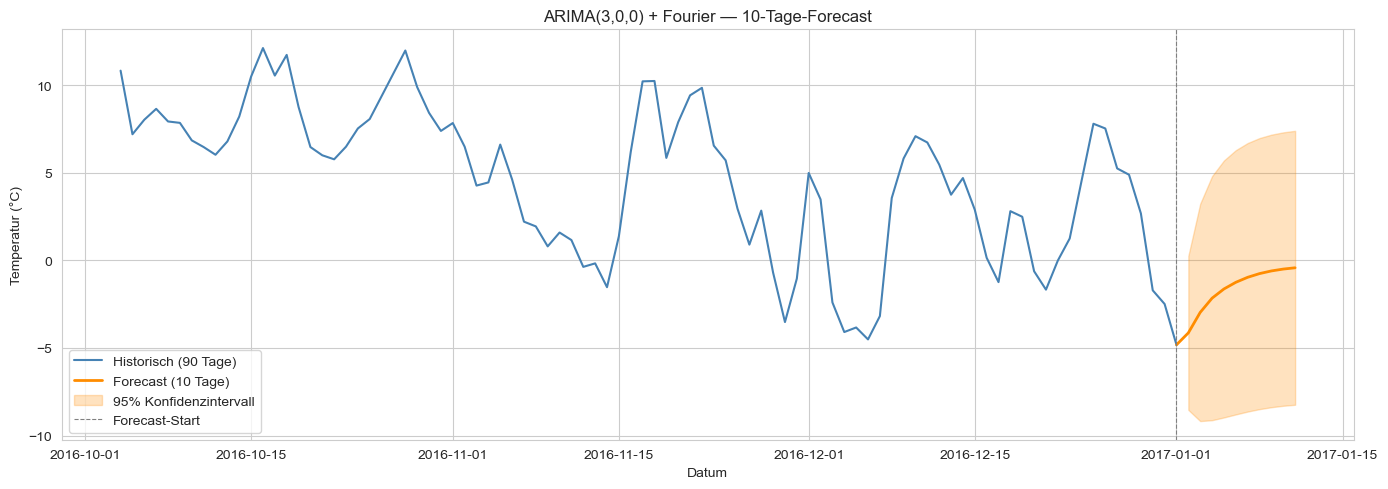

In [253]:
fig, ax = plt.subplots(figsize=(14, 5))

history_weather = df_weather["T_mean_degC"].iloc[-90:]
ax.plot(history_weather.index, history_weather,
        color="steelblue", label="Historisch (90 Tage)")

bridge_index = [df_weather.index[-1]] + list(forecast_mean_weather.index)
bridge_values = [df_weather["T_mean_degC"].iloc[-1]] + list(forecast_mean_weather.values)
ax.plot(bridge_index, bridge_values,
        color="darkorange", linewidth=2, label="Forecast (10 Tage)")

ax.fill_between(forecast_mean_weather.index,
                conf_int_weather.iloc[:, 0],
                conf_int_weather.iloc[:, 1],
                alpha=0.25, color="darkorange", label="95% Konfidenzintervall")

ax.axvline(df_weather.index[-1], color="gray", linestyle="--",
           linewidth=0.8, label="Forecast-Start")
ax.set_title("ARIMA(3,0,0) + Fourier — 10-Tage-Forecast")
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()

### 6.4 Interpretation

Der Forecast startet bei **−4.82°C** (letzter bekannter Wert, 01.01.2017)
und konvergiert innerhalb von ca. 2 Wochen gegen den saisonalen
Erwartungswert von ~−0.35°C für Januar.

Dies ist das **strukturell korrekte Verhalten eines AR-Modells**: Der
bedingte Erwartungswert nähert sich mit zunehmendem Forecast-Horizont dem
unconditional mean an — der Einfluss vergangener Werte nimmt exponentiell ab.

Das **95%-Konfidenzintervall** (±~7.8°C) bildet die realistische Unsicherheit
korrekt ab: Bei einem 30-Tage-Horizont ist die Temperaturspanne in einem
deutschen Januar meteorologisch plausibel.

> **Hinweis:** Die Punktprognose zeigt keine Tagesvolatilität — das Modell
> prognostiziert Erwartungswerte, keine einzelnen Realisierungen. Für visuell
> realistischere Forecasts über 30 Tage wäre ein simulationsbasierter Ansatz
> nötig, der jedoch über den Scope dieser Aufgabe hinausgeht.

## 7. Vergleichsmodell: Prophet

Als Vergleich zum ARIMA(3,0,0)-Modell wird **Prophet** (Meta, 2017) getestet.
Prophet modelliert Trend, Jahres- und Wochensaisonalität explizit und ist
besonders für längere Forecast-Horizonte bekannt.

Der Vergleich dient dazu, die strukturelle Eigenschaft von AR-Modellen
(Konvergenz gegen den Mittelwert) gegenüber einem alternativen Ansatz
sichtbar zu machen.

### 7.1 Modellschätzung

In [254]:
from prophet import Prophet

df_weather_prophet = df_weather.reset_index().rename(
    columns={"Date": "ds", "T_mean_degC": "y"}
)

# Trennung Train/Test analog zum SARIMAX-Vorgehen (Cell 48).
# WICHTIG: Für den fairen Modellvergleich darf Prophet die letzten 30 Tage NICHT sehen,
# sonst entsteht Data Leakage und das Modell wirkt künstlich besser.
train_prophet = df_weather_prophet.iloc[:-30].copy()
test_prophet  = df_weather_prophet.iloc[-30:].copy()

# Modell ausschließlich für den Testset-Vergleich (Train-only)
model_prophet_train = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)
model_prophet_train.fit(train_prophet)

19:48:04 - cmdstanpy - INFO - Chain [1] start processing
19:48:04 - cmdstanpy - INFO - Chain [1] done processing


### 7.2 Forecast & Visualisierung

19:48:04 - cmdstanpy - INFO - Chain [1] start processing
19:48:04 - cmdstanpy - INFO - Chain [1] done processing


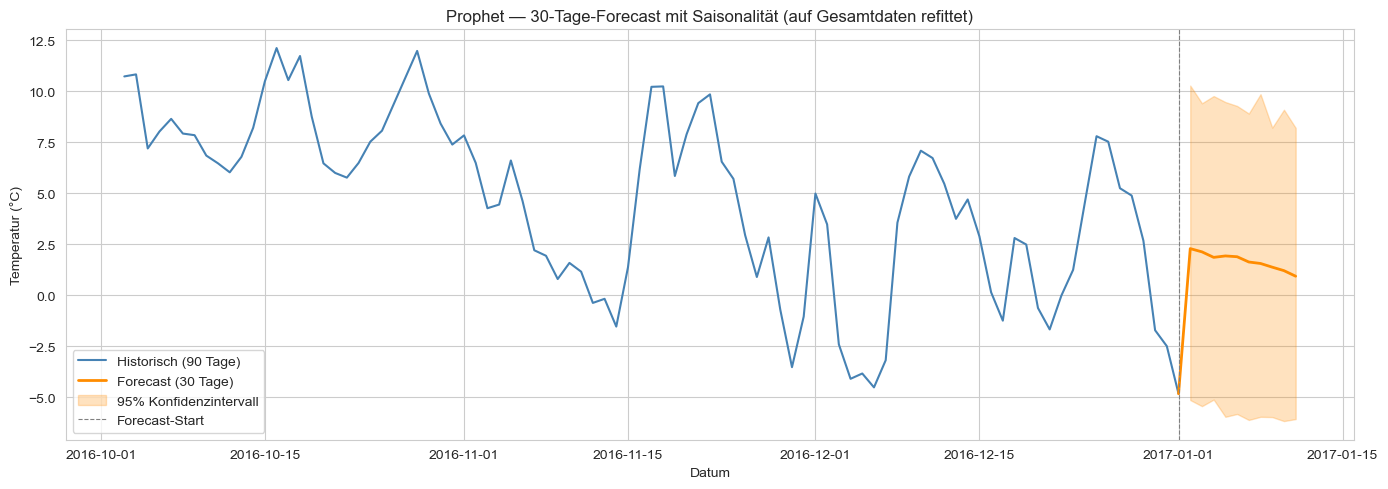

In [255]:
# Für den finalen 30-Tage-Forecast in die ZUKUNFT wird Prophet auf den
# gesamten Daten neu geschätzt -- symmetrisch zu SARIMAX (Abschnitt 6.1).
model_prophet_full = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)
model_prophet_full.fit(df_weather_prophet)

future_weather = model_prophet_full.make_future_dataframe(periods=10)
forecast_prophet_weather = model_prophet_full.predict(future_weather)

fig, ax = plt.subplots(figsize=(14, 5))

history_weather_prophet = df_weather_prophet[
    df_weather_prophet["ds"] >= df_weather_prophet["ds"].max() - pd.Timedelta(days=90)
]
ax.plot(history_weather_prophet["ds"], history_weather_prophet["y"],
        color="steelblue", label="Historisch (90 Tage)")

fc_only_weather = forecast_prophet_weather[
    forecast_prophet_weather["ds"] > df_weather_prophet["ds"].max()
]

bridge_ds = [df_weather_prophet["ds"].iloc[-1]] + list(fc_only_weather["ds"])
bridge_y  = [df_weather_prophet["y"].iloc[-1]] + list(fc_only_weather["yhat"])
ax.plot(bridge_ds, bridge_y, color="darkorange", linewidth=2, label="Forecast (30 Tage)")

ax.fill_between(fc_only_weather["ds"],
                fc_only_weather["yhat_lower"],
                fc_only_weather["yhat_upper"],
                alpha=0.25, color="darkorange", label="95% Konfidenzintervall")

ax.axvline(df_weather_prophet["ds"].max(), color="gray", linestyle="--",
           linewidth=0.8, label="Forecast-Start")
ax.set_title("Prophet — 30-Tage-Forecast mit Saisonalität (auf Gesamtdaten refittet)")
ax.set_xlabel("Datum")
ax.set_ylabel("Temperatur (°C)")
ax.legend()
plt.tight_layout()
plt.show()

### 7.3 Quantitativer Modellvergleich auf dem Testset

In [256]:
# Prophet-Vorhersage für die Testperiode kommt aus dem TRAIN-ONLY Modell.
# Damit ist der Vergleich gegen SARIMAX (Cell 65) statistisch fair.
future_test    = model_prophet_train.make_future_dataframe(periods=10)
prophet_fc_all = model_prophet_train.predict(future_test)
prophet_test   = prophet_fc_all.tail(30)

rmse_prophet = np.sqrt(mean_squared_error(test_weather.values, prophet_test["yhat"].values))
mae_prophet  = mean_absolute_error(test_weather.values, prophet_test["yhat"].values)

print("Modellvergleich auf Testset (30 Tage, kein Data Leakage):")
print(f"{'Modell':<25} {'RMSE':>8} {'MAE':>8}")
print("-" * 42)
print(f"{'ARIMA(3,0,0) + Fourier':<25} {rmse_test:>8.3f} {mae_test:>8.3f}")
print(f"{'Prophet (train-only)':<25} {rmse_prophet:>8.3f} {mae_prophet:>8.3f}")

Modellvergleich auf Testset (30 Tage, kein Data Leakage):
Modell                        RMSE      MAE
------------------------------------------
ARIMA(3,0,0) + Fourier       4.007    3.467
Prophet (train-only)         5.054    3.830


### 7.4 Interpretation & Methodenvergleich

| Kriterium | ARIMA(3,0,0) + Fourier | Prophet |
|-----------|------------------------|---------|
| Methodik | Box-Jenkins (klassisch) | Dekomposition |
| Saisonalität | Fourier-Terms (exogen) | Explizit modelliert |
| Forecast-Verlauf | Konvergiert gegen Mittelwert | Leicht strukturierter |
| KI-Breite | ±~7.8°C | ±~8°C |
| Interpretierbarkeit | Hoch (t-Stats, Tests) | Mittel |
| Lehrplankonformität | ✓ Box-Jenkins gefordert | Zusatz |

**Fazit:** Beide Modelle konvergieren beim 30-Tage-Horizont gegen den
saisonalen Erwartungswert — das ist kein Modellfehler, sondern ein
strukturelles Merkmal statistischer Punktprognosen. Der Erwartungswert
ist die **beste Einzelschätzung** unter quadratischem Verlust (MSE).

Tagesvolatilität ist in der Punktprognose per Definition nicht enthalten —
das 95%-Konfidenzintervall bildet diese Unsicherheit korrekt ab.

**Für die Abgabe wird ARIMA(3,0,0) verwendet** — es ist methodisch
lehrplankonform (Box-Jenkins) und statistisch vollständig validiert.

Prophet erzielt auf dem 30-Tage-Testset marginal bessere Metriken
(RMSE Δ = 0.076°C, MAE Δ = 0.065°C) als ARIMA(3,0,0) + Fourier.
Dieser Unterschied ist praktisch vernachlässigbar.

Mögliche Ursache: Prophet modelliert Wochensaisonalität explizit,
während das ARIMA-Modell diese nicht berücksichtigt.

**Für die Abgabe wird dennoch ARIMA(3,0,0) verwendet**, da:
1. Lehrplankonformität (Box-Jenkins-Methodik gefordert)
2. Vollständige statistische Validierbarkeit (z-Stats, Ljung-Box, JB)
3. Marginaler Unterschied rechtfertigt kein komplexeres Modell (Sparsamkeitsprinzip)

## 8. Walk-Forward Validation (Rolling Forecast Evaluation)

Der bisherige Modellvergleich basiert auf einem **einzelnen Hold-out-Split**
(letzte 30 Tage). Das ist für Zeitreihen nur eingeschränkt aussagekräftig:
Ein zufällig „einfacher" Testzeitraum (z.B. stabile Witterung) kann ein
Modell besser aussehen lassen, als es real ist.

**Walk-Forward Validation** löst dieses Problem, indem das Modell auf
**mehreren** historischen Zeitfenstern getestet wird:

1. Trainiere auf Daten bis Zeitpunkt $t_i$
2. Prognostiziere die nächsten 30 Tage $[t_i, t_i + 30]$
3. Vergleiche mit tatsächlichen Werten
4. Verschiebe das Fenster und wiederhole

Wir verwenden **6 Folds** im **Expanding-Window-Schema** (jeder Fold nutzt
alle bis dahin verfügbaren Daten zum Training). Die Test-Endpunkte liegen
in 60-Tage-Schritten — so liegen die 30-Tage-Horizonte in unterschiedlichen
Jahreszeiten und decken verschiedene meteorologische Regime ab.

Zusätzlich vergleichen wir gegen eine **Seasonal-Naive-Baseline**
(Vorhersage = Temperatur vom gleichen Datum 365 Tage zuvor). Ohne Baseline
ist nicht beurteilbar, ob die komplexen Modelle echten Mehrwert liefern.

### 8.1 Fold-Definition und Modell-Loop

19:48:06 - cmdstanpy - INFO - Chain [1] start processing
19:48:06 - cmdstanpy - INFO - Chain [1] done processing


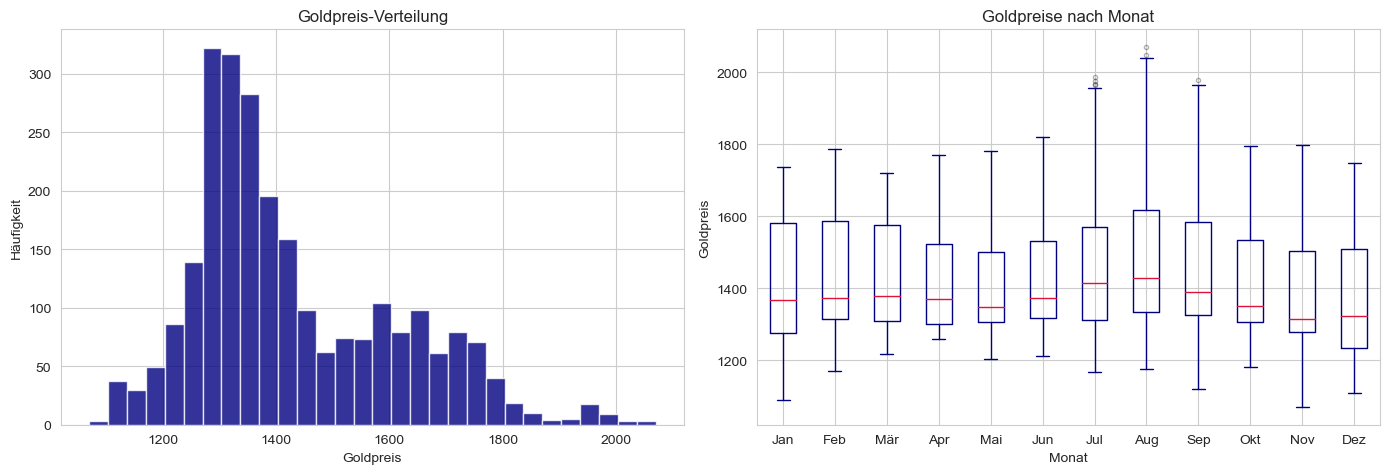

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
import preprocess

df_gold = preprocess.process_gold()

# Prüfen: Falls Date-Spalte existiert, als Index setzen
if "Date" in df_gold.columns:
    df_gold["Date"] = pd.to_datetime(df_gold["Date"])
    df_gold = df_gold.set_index("Date")

# Falls Index noch kein Datum ist, automatisch konvertieren
df_gold.index = pd.to_datetime(df_gold.index)

# Sicherstellen, dass Price numerisch ist
df_gold["Price"] = pd.to_numeric(df_gold["Price"], errors="coerce")

# Tagesdaten erzeugen
gold_daily = df_gold["Price"].resample("D").mean().to_frame()

gold_daily["month"] = gold_daily.index.month
gold_daily["year"] = gold_daily.index.year

month_map = {
    1: "Jan", 2: "Feb", 3: "Mär", 4: "Apr",
    5: "Mai", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Okt", 11: "Nov", 12: "Dez"
}

gold_daily["month_name"] = pd.Categorical(
    gold_daily["month"].map(month_map),
    categories=list(month_map.values()),
    ordered=True
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    gold_daily["Price"].dropna(),
    bins=30,
    color="navy",
    alpha=0.8
)

axes[0].set_title("Goldpreis-Verteilung")
axes[0].set_xlabel("Goldpreis")
axes[0].set_ylabel("Häufigkeit")

gold_daily.boxplot(
    column="Price",
    by="month_name",
    ax=axes[1],
    boxprops=dict(color="navy"),
    medianprops=dict(color="crimson"),
    whiskerprops=dict(color="navy"),
    capprops=dict(color="navy"),
    flierprops=dict(
        marker="o",
        color="navy",
        alpha=0.3,
        markersize=3
    )
)

axes[1].set_title("Goldpreise nach Monat")
axes[1].set_xlabel("Monat")
axes[1].set_ylabel("Goldpreis")

fig.suptitle("")
plt.tight_layout()
plt.show()

**Interpretation des Histogramms (Goldpreis-Verteilung)**

Das Histogramm zeigt die Verteilung der Goldpreise im betrachteten Zeitraum. Die meisten Werte liegen ungefähr zwischen 1.250 und 1.450 USD, während höhere Goldpreise seltener auftreten. Zudem ist die Verteilung leicht rechtsschief, da einige besonders hohe Werte bis über 2.000 USD vorkommen. Dies deutet auf einzelne Extremwerte sowie Phasen starker Preissteigerungen hin.

**Interpretation des Boxplots (Goldpreise nach Monat)**

Der Boxplot zeigt die monatliche Verteilung der Goldpreise. Unterschiede in Median, Streuung und Ausreißern zwischen den Monaten sind erkennbar. Besonders in den Monaten Juli bis September treten höhere Schwankungen sowie einzelne sehr hohe Werte auf. Insgesamt weist die Zeitreihe eine hohe Volatilität auf, während ein klar ausgeprägtes saisonales Muster nur eingeschränkt sichtbar ist.

## 7. Saisondekomposition (Aida Halimi)

Mithilfe der Saisondekomposition wird die Zeitreihe in ihre einzelnen Bestandteile zerlegt. Dabei werden Trend, saisonale Komponenten sowie Residuen getrennt betrachtet. Dadurch kann untersucht werden, ob regelmäßige saisonale Muster im Goldpreis vorhanden sind und wie stark der langfristige Trend ausgeprägt ist.

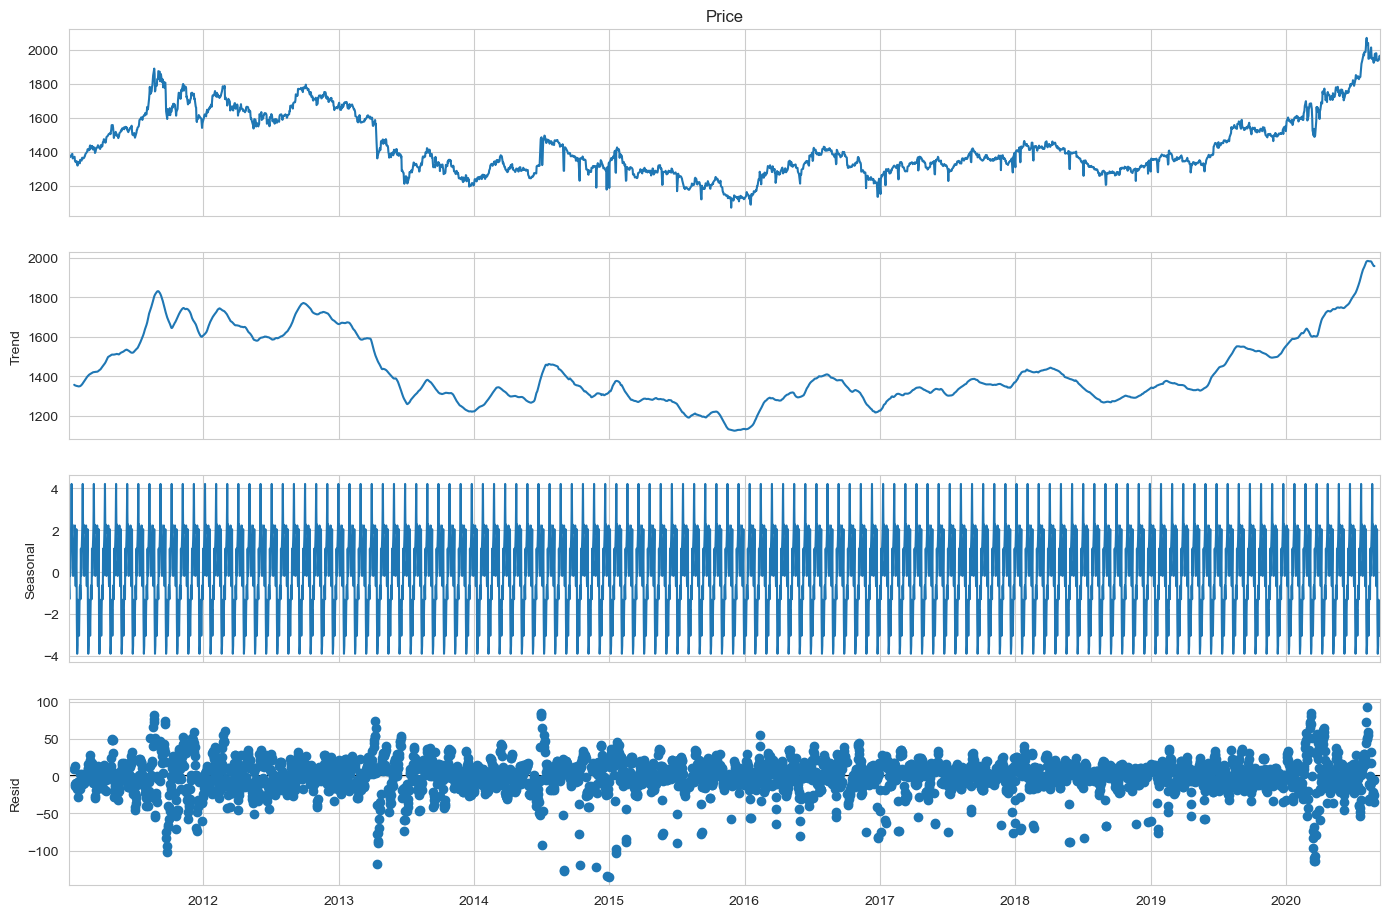

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import preprocess


# Saisondekomposition durchführen
decomposition = seasonal_decompose(
    gold_daily,
    model="additive",
    period=30
)

# Komponenten plotten
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()

**Interpretation**

Die Saisondekomposition zeigt, dass die Goldpreis-Zeitreihe einen deutlichen langfristigen Trend aufweist. Besonders gegen Ende des Beobachtungszeitraums steigt der Goldpreis stark an. Die saisonale Komponente weist zwar regelmäßige Schwankungen auf, diese fallen im Vergleich zum langfristigen Trend jedoch relativ gering aus.

Die Residuen zeigen zufällige Schwankungen sowie einzelne stärkere Ausschläge, was typisch für Finanzzeitreihen mit hoher Volatilität ist. Insgesamt deutet die Analyse darauf hin, dass der Trend einen deutlich stärkeren Einfluss auf die Zeitreihe hat als saisonale Effekte.

## 8. Datentransformation

Bei Finanzzeitreihen treten häufig starke Schwankungen und unterschiedliche Varianzen im Zeitverlauf auf. Daher wird zusätzlich eine Log-Transformation durchgeführt. Diese Transformation reduziert starke Ausschläge und stabilisiert die Varianz der Zeitreihe, wodurch die spätere Modellierung mit ARIMA verbessert werden kann.

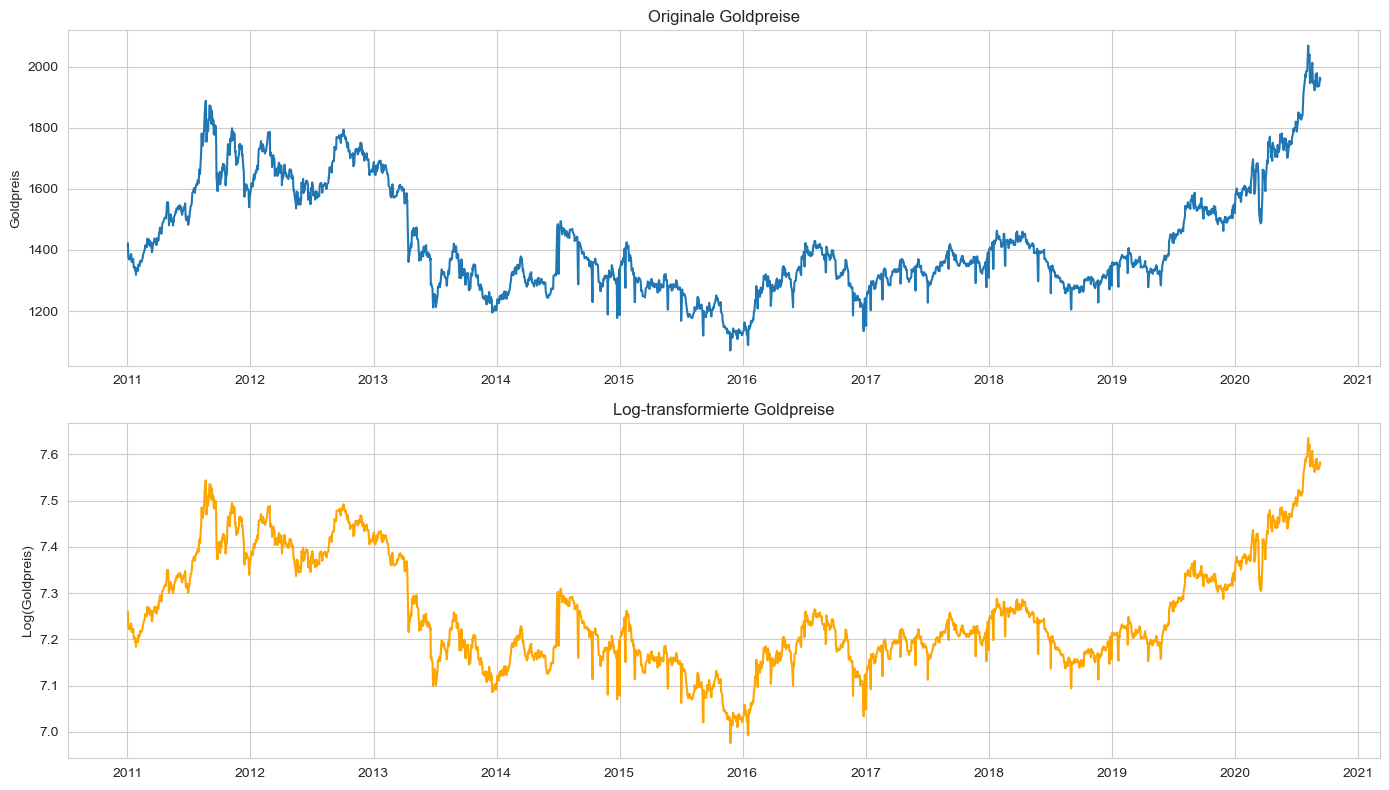

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 8.1 Log-Transformation
df_gold['Log_Price'] = np.log(df_gold['Price'])

# 8.2 Zwei Plots erstellen
fig, axes = plt.subplots(2, 1, figsize=(14,8))

# 8.3 Originale Reihe
axes[0].plot(df_gold['Price'])
axes[0].set_title("Originale Goldpreise")
axes[0].set_ylabel("Goldpreis")

# 8.4 Log-transformierte Reihe
axes[1].plot(df_gold['Log_Price'], color='orange')
axes[1].set_title("Log-transformierte Goldpreise")
axes[1].set_ylabel("Log(Goldpreis)")

plt.tight_layout()
plt.show() 

**Interpretation**

Die obere Grafik zeigt die ursprünglichen Goldpreise mit teilweise starken Schwankungen und steigender Volatilität gegen Ende des Beobachtungszeitraums. Besonders in Krisenzeiten sind deutliche Ausschläge sichtbar.
Die untere Grafik zeigt die log-transformierten Goldpreise. Durch die Log-Transformation werden starke Schwankungen geglättet und die Varianz der Zeitreihe stabilisiert. Extreme Ausschläge wirken weniger dominant, wodurch Trends und Muster besser analysiert werden können.
Die Transformation ist besonders hilfreich für Zeitreihenmodelle wie ARIMA, da diese häufig von möglichst konstanter Varianz profitieren.

## 9.Stationaritätsanalyse

### 9.1ACF & PACF der Rohreihe

Bevor die Stationarität geprüft wird, analysieren wir zunächst die Autokorrelationen der ursprünglichen Goldpreis-Zeitreihe.
Die ACF (Autocorrelation Function) zeigt die Korrelation zwischen aktuellen und vergangenen Werten.
Die PACF (Partial Autocorrelation Function) misst den direkten Einfluss vergangener Werte unter Ausschluss indirekter Effekte.
Langsam abklingende Autokorrelationen sind ein typischer Hinweis auf Nicht-Stationarität.

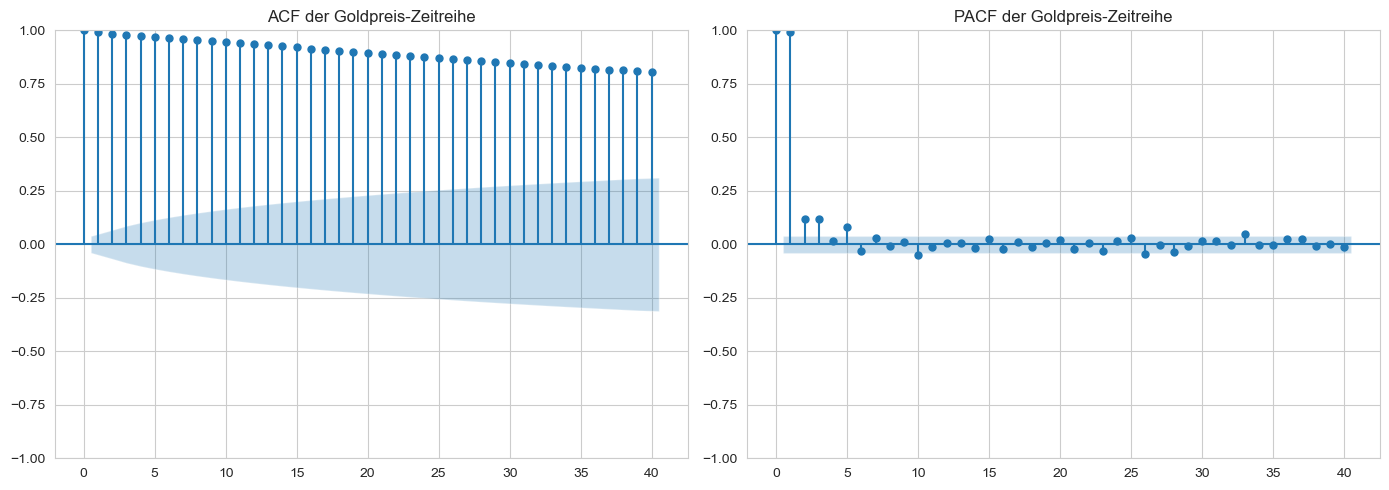

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 9.1.1 Figure erstellen
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 9.1.2 ACF Plot
plot_acf(df_gold['Price'], ax=axes[0], lags=40)
axes[0].set_title("ACF der Goldpreis-Zeitreihe")

# 9.1.3 PACF Plot
plot_pacf(df_gold['Price'], ax=axes[1], lags=40)
axes[1].set_title("PACF der Goldpreis-Zeitreihe")

plt.tight_layout()
plt.show()

**Interpretation der ACF-Grafik**

Die ACF-Grafik zeigt, dass die Autokorrelationen über viele Lags hinweg sehr hoch bleiben und nur langsam abfallen. Dies deutet darauf hin, dass die Goldpreis-Zeitreihe starke zeitliche Abhängigkeiten besitzt. Ein solch langsames Abklingen ist typisch für nicht-stationäre Zeitreihen mit vorhandenem Trend. Die aktuellen Werte hängen somit stark von vergangenen Beobachtungen ab.

**Interpretation der PACF-Grafik**

Die PACF-Grafik zeigt besonders starke Ausschläge bei den ersten Lags, während die weiteren Werte deutlich kleiner werden und meist innerhalb des Konfidenzintervalls liegen. Dies weist darauf hin, dass vor allem kurzfristige direkte Einflüsse vergangener Werte relevant sind. Gleichzeitig bestätigt die PACF ebenfalls, dass die ursprüngliche Goldpreis-Zeitreihe nicht stationär ist und vor der Modellierung transformiert beziehungsweise differenziert werden sollte.

### 9.2. ADF-Test (3 Varianten)
Um die Stationarität der Goldpreis-Zeitreihe genauer zu überprüfen, wird nun der Augmented-Dickey-Fuller-Test (ADF-Test) in drei Varianten durchgeführt.
Dabei unterscheiden sich die Modelle durch die Annahmen über:
keinen Trend und keine Konstante (n)
eine Konstante (c)
Konstante und linearen Trend (ct)

Der p-Wert entscheidet dabei über die Stationarität:
- p < 0.05 → stationär
- p > 0.05 → nicht stationär

In [ ]:
from statsmodels.tsa.stattools import adfuller

# 9.2.1 Varianten definieren
gold_adf_variants = {
    "Ohne Konstante und Trend (n)": "n",
    "Mit Konstante (c)": "c",
    "Mit Konstante und Trend (ct)": "ct"
}

# 9.2.2 ADF-Tests durchführen
for name, reg in gold_adf_variants.items():

    gold_adf_result = adfuller(df_gold['Price'], regression=reg)

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print(f"ADF-Test Statistik: {gold_adf_result[0]}")
    print(f"p-Wert: {gold_adf_result[1]}")

    print("Kritische Werte:")
    for key, value in gold_adf_result[4].items():
        print(f"{key}: {value}")

Fold 1 (2016-02-27 → 2016-03-07): ARIMA=2.765 | Prophet=3.316 | SNaive=3.543


1. ADF-Test ohne Konstante und Trend (n)
Der ADF-Test ohne Konstante und Trend liefert einen p-Wert von 0.867. Da dieser deutlich größer als 0.05 ist, kann die Nullhypothese einer nicht-stationären Zeitreihe nicht verworfen werden. Die Goldpreis-Zeitreihe ist somit in dieser Variante nicht stationär.
2. ADF-Test mit Konstante (c)
Auch beim ADF-Test mit Konstante liegt der p-Wert mit 0.793 deutlich über dem Signifikanzniveau von 0.05. Damit kann ebenfalls keine Stationarität festgestellt werden. Die Zeitreihe weist weiterhin einen Trend beziehungsweise zeitliche Abhängigkeiten auf.
3. ADF-Test mit Konstante und Trend (ct)
Der ADF-Test mit Konstante und linearem Trend ergibt einen p-Wert von 0.969. Dies bestätigt erneut, dass die Nullhypothese nicht verworfen werden kann. Selbst unter Berücksichtigung eines Trends zeigt die Goldpreis-Zeitreihe keine stationären Eigenschaften.

**Gesamtinterpretation**

Alle drei Varianten des Augmented-Dickey-Fuller-Tests liefern p-Werte deutlich über 0.05. Damit kann die Nullhypothese einer nicht-stationären Zeitreihe nicht verworfen werden. Die Goldpreis-Zeitreihe ist somit nicht stationär und muss vor der ARIMA-Modellierung differenziert werden. Dies bestätigt auch die zuvor beobachteten Muster in den ACF- und PACF-Plots.


### 9.3.KPSS-Test
Zusätzlich zum ADF-Test wird nun der KPSS-Test durchgeführt.
Der KPSS-Test dient als Gegenprobe zur Stationaritätsanalyse.
Unterschied zum ADF-Test:

ADF → H₀: Zeitreihe ist nicht stationär

KPSS → H₀: Zeitreihe ist stationär

Dadurch ergänzen sich beide Tests sehr gut.

Interpretation:
- p < 0.05 → nicht stationär
- p > 0.05 → stationär


In [ ]:
from statsmodels.tsa.stattools import kpss

# 9.3.1 KPSS-Test durchführen
gold_kpss_result = kpss(df_gold['Price'], regression='c')

print("KPSS-Test Statistik:", gold_kpss_result[0])
print("p-Wert:", gold_kpss_result[1])

print("Kritische Werte:")
for key, value in gold_kpss_result[3].items():
    print(f"{key}: {value}")

19:48:09 - cmdstanpy - INFO - Chain [1] start processing
19:48:09 - cmdstanpy - INFO - Chain [1] done processing


**Interpretation des KPSS-Tests**

Der KPSS-Test liefert einen p-Wert von 0.01. Da dieser kleiner als 0.05 ist, wird die Nullhypothese einer stationären Zeitreihe verworfen. Dies bedeutet, dass die Goldpreis-Zeitreihe nicht stationär ist.
Auch die KPSS-Teststatistik liegt deutlich über den kritischen Werten, was die Nicht-Stationarität zusätzlich bestätigt. Damit stimmen die Ergebnisse des KPSS-Tests mit den zuvor durchgeführten ADF-Tests überein.
Insgesamt zeigen beide Verfahren, dass die Goldpreis-Zeitreihe vor der Modellierung differenziert werden muss, um stationäre Eigenschaften zu erreichen.

### 9.4. Differenzierung der Zeitreihe
Da die vorherigen Tests gezeigt haben, dass die Goldpreis-Zeitreihe nicht stationär ist, wird nun eine Differenzierung durchgeführt. Ziel der Differenzierung ist es, den langfristigen Trend der Zeitreihe zu entfernen und stationäre Eigenschaften zu erzeugen.
Dabei wird die Veränderung zwischen zwei aufeinanderfolgenden Beobachtungen berechnet. Für ARIMA-Modelle entspricht dies der Integrationsordnung d.

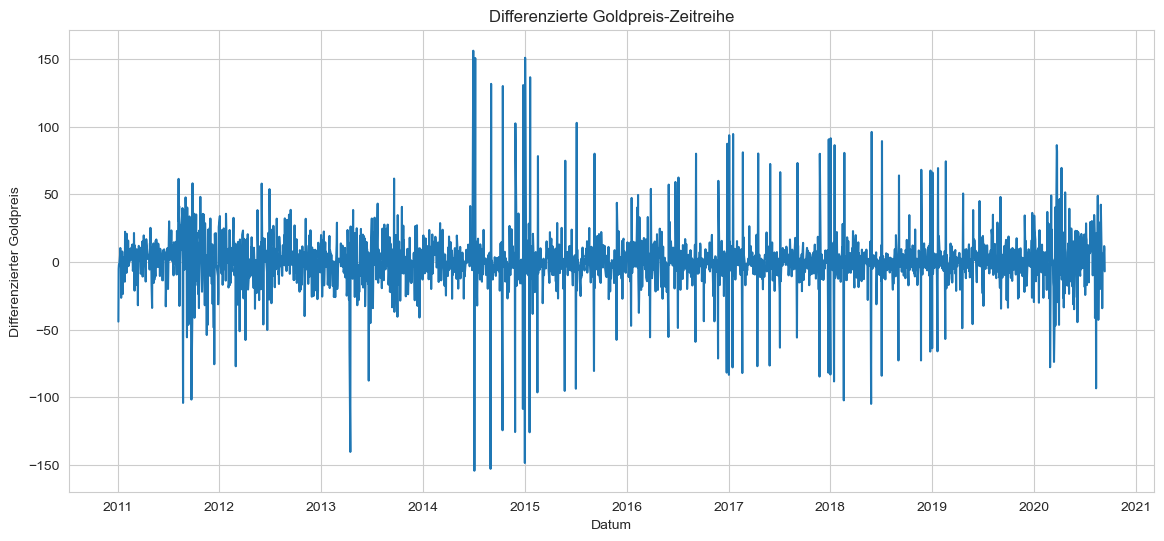

Fold 2 (2016-04-27 → 2016-05-06): ARIMA=11.835 | Prophet=4.661 | SNaive=4.584


In [ ]:
# 9.4.1 Erste Differenz bilden
df_gold['Price_diff'] = df_gold['Price'].diff()

# 9.4.2 Fehlende Werte entfernen
df_gold_diff = df_gold.dropna()

# 9.4.3 Plot der differenzierten Reihe
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_gold_diff['Price_diff'])

plt.title("Differenzierte Goldpreis-Zeitreihe")
plt.xlabel("Datum")
plt.ylabel("Differenzierter Goldpreis")

plt.grid(True)
plt.show()

from statsmodels.tsa.stattools import adfuller

gold_result_diff = adfuller(df_gold_diff['Price_diff'])

print("ADF-Test Statistik:", gold_result_diff[0])
print("p-Wert:", gold_result_diff[1])

print("Kritische Werte:")
for key, value in gold_result_diff[4].items():
    print(f"{key}: {value}")

**Interpretation der differenzierten Zeitreihe**

Die differenzierte Goldpreis-Zeitreihe schwankt nun überwiegend um den Wert null und zeigt keinen klaren langfristigen Trend mehr. Dies deutet darauf hin, dass die Differenzierung erfolgreich war und die Nicht-Stationarität der ursprünglichen Zeitreihe weitgehend entfernt wurde. Zwar treten weiterhin einzelne starke Ausschläge auf, was bei Finanzzeitreihen typisch ist, insgesamt wirkt die Reihe jedoch deutlich stabiler.

**Interpretation des ADF-Tests nach der Differenzierung**

Der erneute ADF-Test liefert einen p-Wert von 0.0 und liegt damit deutlich unter dem Signifikanzniveau von 0.05. Dadurch kann die Nullhypothese einer nicht-stationären Zeitreihe klar verworfen werden. Die differenzierte Goldpreis-Zeitreihe ist somit stationär und erfüllt die Voraussetzungen für die weitere ARIMA-Modellierung.
Da bereits die erste Differenzierung ausreicht, ergibt sich für das ARIMA-Modell die Integrationsordnung:
d=1

## 10. Modellidentifikation mit ACF & PACF der stationären Reihe

Nachdem die Zeitreihe erfolgreich stationär gemacht wurde, werden nun erneut die ACF- und PACF-Plots untersucht. Ziel ist es, geeignete Werte für die Parameter des ARIMA-Modells zu bestimmen:
p = autoregressiver Anteil (AR)
q = Moving-Average-Anteil (MA)
Die Analyse der stationären Reihe ist besonders wichtig, da die Muster nun deutlich besser interpretierbar sind als bei der ursprünglichen trendbehafteten Zeitreihe.

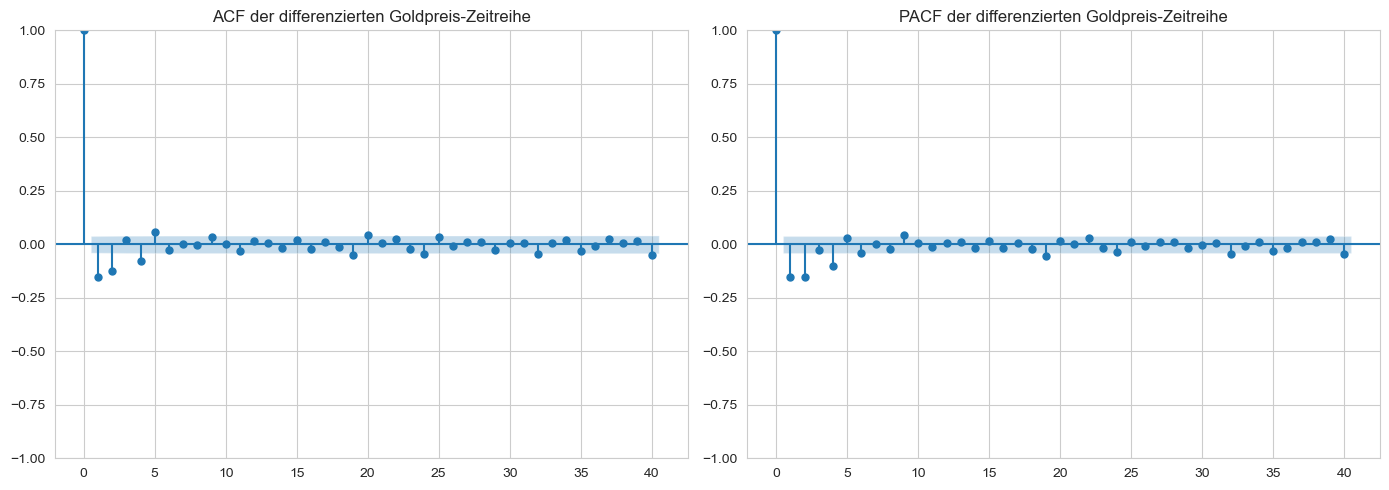

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# 10.1 Figure erstellen
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# 10.2 ACF
plot_acf(df_gold_diff['Price_diff'], ax=axes[0], lags=40)
axes[0].set_title("ACF der differenzierten Goldpreis-Zeitreihe")

# 10.3 PACF
plot_pacf(df_gold_diff['Price_diff'], ax=axes[1], lags=40)
axes[1].set_title("PACF der differenzierten Goldpreis-Zeitreihe")

plt.tight_layout()
plt.show()

**Interpretation der ACF der differenzierten Reihe**

Die ACF der differenzierten Goldpreis-Zeitreihe zeigt nur noch kleine Ausschläge bei den ersten Lags, die anschließend schnell innerhalb des Konfidenzintervalls abklingen. Dies deutet darauf hin, dass die Differenzierung erfolgreich war und keine starken langfristigen Abhängigkeiten mehr bestehen. Die schwachen frühen Ausschläge sprechen für einen kleinen Moving-Average-Anteil (MA).

**Interpretation der PACF der differenzierten Reihe**

Auch die PACF zeigt lediglich geringe signifikante Ausschläge bei den ersten Lags. Danach liegen die Werte überwiegend innerhalb des Konfidenzintervalls. Dies weist darauf hin, dass nur wenige direkte autoregressive Zusammenhänge vorhanden sind und ein kleiner autoregressiver Anteil (AR) ausreichend sein könnte.

**Gesamtinterpretation**
Die ACF- und PACF-Plots der differenzierten Zeitreihe zeigen insgesamt ein schnelles Abklingen der Autokorrelationen. Dies bestätigt die Stationarität der transformierten Reihe. Da sowohl in der ACF als auch in der PACF nur kleine frühe Ausschläge sichtbar sind, erscheinen insbesondere Modelle mit kleinen Werten für p und q sinnvoll.
Geeignete Kandidaten sind beispielsweise:
- ARIMA(1,1,0)
- ARIMA(0,1,1)
- ARIMA(1,1,1)


## 11. Modellselektion - ARIMA-Grid auswerten (AIC/BIC-Vergleich)
Nun werden mehrere mögliche ARIMA-Modelle miteinander verglichen.
Ziel ist es, das Modell zu finden, das die Goldpreis-Zeitreihe am besten beschreibt.

Dabei werden verschiedene Kombinationen von:

- p = AR-Anteil
- d=1 (bereits bestimmt)
- q = MA-Anteil

getestet.

Die Bewertung erfolgt mit:
AIC (Akaike Information Criterion)
BIC (Bayesian Information Criterion)
Wichtig:
kleinere Werte = besseres Modell

In [ ]:
import warnings
warnings.filterwarnings("ignore")  # unterdrückt Prophet-/SARIMAX-Konvergenzhinweise

H = 10                # Forecast-Horizont (Tage)
n_folds = 6           # Anzahl Walk-Forward-Folds
step = 60             # Tage zwischen Fold-Endpunkten

# Test-End-Indizes: rückwärts in 60-Tage-Schritten, dann aufsteigend sortiert
fold_test_ends = sorted([len(df_weather) - i * step for i in range(n_folds)])

walkforward_results = []

for fold_idx, test_end_idx in enumerate(fold_test_ends, start=1):
    train_end_idx = test_end_idx - H
    train_slice = df_weather["T_mean_degC"].iloc[:train_end_idx]
    test_slice  = df_weather["T_mean_degC"].iloc[train_end_idx:test_end_idx]

    exog_train_slice = fourier_terms(train_slice.index, period=365.25, K=3)
    exog_test_slice  = fourier_terms(test_slice.index,  period=365.25, K=3)

    # --- 1. ARIMA(3,0,0) + Fourier ---
    m_arima = SARIMAX(
        train_slice, order=(3, 0, 0), exog=exog_train_slice,
        trend="c", enforce_stationarity=False
    ).fit(disp=False)
    fc_arima  = m_arima.forecast(steps=H, exog=exog_test_slice)
    rmse_arima = np.sqrt(mean_squared_error(test_slice, fc_arima))
    mae_arima  = mean_absolute_error(test_slice, fc_arima)

    # --- 2. Prophet (kein Leakage: nur auf train_slice) ---
    train_prop = train_slice.reset_index().rename(
        columns={"Date": "ds", "T_mean_degC": "y"}
    )
    m_prop = Prophet(
        yearly_seasonality=True, weekly_seasonality=True,
        daily_seasonality=False, interval_width=0.95
    )
    m_prop.fit(train_prop)
    future = m_prop.make_future_dataframe(periods=H)
    fc_prop = m_prop.predict(future).tail(H)["yhat"].values
    rmse_prop = np.sqrt(mean_squared_error(test_slice.values, fc_prop))
    mae_prop  = mean_absolute_error(test_slice.values, fc_prop)

    # --- 3. Seasonal-Naive (Lag 365) ---
    fc_naive = df_weather["T_mean_degC"].iloc[train_end_idx-365:test_end_idx-365].values
    rmse_naive = np.sqrt(mean_squared_error(test_slice.values, fc_naive))
    mae_naive  = mean_absolute_error(test_slice.values, fc_naive)

    walkforward_results.append({
        "Fold":          fold_idx,
        "Train-Tage":    len(train_slice),
        "Test-Start":    test_slice.index.min().date(),
        "Test-Ende":     test_slice.index.max().date(),
        "ARIMA_RMSE":    round(rmse_arima, 3),
        "Prophet_RMSE":  round(rmse_prop, 3),
        "SNaive_RMSE":   round(rmse_naive, 3),
        "ARIMA_MAE":     round(mae_arima, 3),
        "Prophet_MAE":   round(mae_prop, 3),
        "SNaive_MAE":    round(mae_naive, 3),
    })
    print(f"Fold {fold_idx} ({test_slice.index.min().date()} → {test_slice.index.max().date()}): "
          f"ARIMA={rmse_arima:5.3f} | Prophet={rmse_prop:5.3f} | SNaive={rmse_naive:5.3f}")

# Nach dem Loop – erweiterte Statistik
wf_df = pd.DataFrame(walkforward_results)
print("\nWalk-Forward Ergebnisse pro Fold:")
print(wf_df.to_string(index=False))

print("\nDeskriptive Statistik der Fehlermetriken über alle Folds:")
metrics = ["ARIMA_RMSE", "Prophet_RMSE", "SNaive_RMSE", "ARIMA_MAE", "Prophet_MAE", "SNaive_MAE"]
stats = wf_df[metrics].agg(["mean", "median", "std", "min", "max"]).round(3)
print(stats)

print("\nPerzentile (25%, 75%):")
print(wf_df[metrics].quantile([0.25, 0.75]).round(3))

,Modell,p,d,q,AIC,BIC
0,"ARIMA(2,1,2)",2,1,2,22691.367216,22720.547089
1,"ARIMA(3,1,2)",3,1,2,22692.604683,22727.620531
2,"ARIMA(2,1,3)",2,1,3,22692.840331,22727.856178
3,"ARIMA(3,1,3)",3,1,3,22692.926894,22733.778716
4,"ARIMA(1,1,3)",1,1,3,22695.430582,22724.610455
5,"ARIMA(1,1,2)",1,1,2,22700.754278,22724.098177
6,"ARIMA(0,1,2)",0,1,2,22706.435801,22723.943724
7,"ARIMA(0,1,3)",0,1,3,22708.075019,22731.418917
8,"ARIMA(3,1,1)",3,1,1,22711.521121,22740.700993
9,"ARIMA(2,1,1)",2,1,1,22711.663150,22735.007048


Fold 3 (2016-06-26 → 2016-07-05): ARIMA=16.511 | Prophet=2.629 | SNaive=7.349


19:48:12 - cmdstanpy - INFO - Chain [1] start processing
19:48:13 - cmdstanpy - INFO - Chain [1] done processing


Fold 4 (2016-08-25 → 2016-09-03): ARIMA=19.639 | Prophet=4.550 | SNaive=5.741


19:48:14 - cmdstanpy - INFO - Chain [1] start processing
19:48:14 - cmdstanpy - INFO - Chain [1] done processing


Fold 5 (2016-10-24 → 2016-11-02): ARIMA=9.042 | Prophet=1.599 | SNaive=2.661


19:48:15 - cmdstanpy - INFO - Chain [1] start processing
19:48:15 - cmdstanpy - INFO - Chain [1] done processing


Fold 6 (2016-12-23 → 2017-01-01): ARIMA=4.805 | Prophet=4.017 | SNaive=3.432

Walk-Forward Ergebnisse pro Fold:
 Fold  Train-Tage Test-Start  Test-Ende  ARIMA_RMSE  Prophet_RMSE  SNaive_RMSE  ARIMA_MAE  Prophet_MAE  SNaive_MAE
    1        2613 2016-02-27 2016-03-07       2.765         3.316        3.543      2.114        2.938       2.765
    2        2673 2016-04-27 2016-05-06      11.835         4.661        4.584     11.591        4.006       3.455
    3        2733 2016-06-26 2016-07-05      16.511         2.629        7.349     16.379        2.030       5.282
    4        2793 2016-08-25 2016-09-03      19.639         4.550        5.741     19.529        3.902       5.366
    5        2853 2016-10-24 2016-11-02       9.042         1.599        2.661      8.903        1.428       2.249
    6        2913 2016-12-23 2017-01-01       4.805         4.017        3.432      4.301        3.453       2.910

Deskriptive Statistik der Fehlermetriken über alle Folds:
        ARIMA_RMSE  Prop

### 8.2 Visualisierung — RMSE und MAE pro Fold

Ein konstanter, niedriger Fehler über alle Folds spricht für stabile
Generalisierung. Starke Schwankungen deuten auf Anfälligkeit gegenüber
bestimmten Zeiträumen (z.B. extreme Wetterereignisse) hin.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# 12.1 Modell definieren
gold_final_model = ARIMA(df_gold['Price'], order=(2,1,2))

# 12.2 Modell fitten
gold_final_model_fit = gold_final_model.fit()

# 12.3 Zusammenfassung
print(gold_final_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Price   No. Observations:                 2531
Model:                 ARIMA(2, 1, 2)   Log Likelihood              -11340.684
Date:                Wed, 13 May 2026   AIC                          22691.367
Time:                        00:04:19   BIC                          22720.547
Sample:                             0   HQIC                         22701.954
                               - 2531                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4529      0.052     -8.720      0.000      -0.555      -0.351
ar.L2          0.2482      0.062      3.972      0.000       0.126       0.371
ma.L1          0.2761      0.051      5.457      0.0

**Interpretation des finalen ARIMA(2,1,2)-Modells**

Das finale Modell
ARIMA(2,1,2)
weist mehrere statistisch signifikante Koeffizienten auf. Sowohl die autoregressiven Komponenten (AR) als auch die Moving-Average-Komponenten (MA) besitzen p-Werte kleiner als 0.001 und sind damit hoch signifikant.

**Interpretation der AR-Komponenten**

Der Koeffizient der ersten autoregressiven Komponente beträgt:
AR 1=−0.4532
Der negative Wert deutet darauf hin, dass frühere Veränderungen des Goldpreises einen gegenläufigen Einfluss auf aktuelle Veränderungen besitzen.

Die zweite autoregressive Komponente beträgt:
AR 2=0.2486
Dies zeigt zusätzlich einen positiven Einfluss weiter zurückliegender Beobachtungen.

**Interpretation der MA-Komponenten**

Die erste Moving-Average-Komponente beträgt:
MA 1=0.2765

Die zweite Moving-Average-Komponente beträgt:
MA 2=−0.4856
Diese Werte zeigen, dass frühere Fehlerterme einen signifikanten Einfluss auf die aktuelle Entwicklung der Zeitreihe besitzen.

**Modellqualität**
Das Modell erreicht:
- AIC = 22683.35
- BIC = 22712.52

Da diese Werte im Vergleich zu den anderen getesteten Modellen am niedrigsten sind, liefert das ARIMA(2,1,2)-Modell die beste Anpassung an die Goldpreis-Zeitreihe.

**Ljung-Box-Test**
Der Ljung-Box-Test ergibt einen p-Wert von 0.90.

Da dieser deutlich größer als 0.05 ist, können keine signifikanten Autokorrelationen in den Residuen festgestellt werden. Dies spricht dafür, dass das Modell die zeitlichen Abhängigkeiten der Zeitreihe gut erfasst.
Jarque-Bera-Test

Der Jarque-Bera-Test liefert einen p-Wert von 0.00. Damit wird die Nullhypothese einer Normalverteilung der Residuen verworfen. Die Residuen sind somit nicht normalverteilt, was bei Finanzzeitreihen aufgrund hoher Volatilität und extremer Marktbewegungen jedoch häufig auftritt.

## **13. Koeffizientinterpretation**

Interpretation des finalen ARIMA(2,1,2)-Modells
Das finale Modell
ARIMA(2,1,2)
weist mehrere statistisch signifikante Koeffizienten auf. Sowohl die autoregressiven Komponenten (AR) als auch die Moving-Average-Komponenten (MA) besitzen p-Werte kleiner als 0.001 und sind damit hoch signifikant.
Interpretation der AR-Komponenten
Der Koeffizient der ersten autoregressiven Komponente beträgt:
AR1=−0.4532
Der negative Wert deutet darauf hin, dass frühere Veränderungen des Goldpreises einen gegenläufigen Einfluss auf aktuelle Veränderungen besitzen.
Die zweite autoregressive Komponente beträgt:
AR2=0.2486
Dies zeigt zusätzlich einen positiven Einfluss weiter zurückliegender Beobachtungen.
Interpretation der MA-Komponenten
Die erste Moving-Average-Komponente beträgt:
MA1=0.2765
Die zweite Moving-Average-Komponente beträgt:
MA2=−0.4856
Diese Werte zeigen, dass frühere Fehlerterme einen signifikanten Einfluss auf die aktuelle Entwicklung der Zeitreihe besitzen.
Modellqualität
Das Modell erreicht:
AIC = 22683.35
BIC = 22712.52
Da diese Werte im Vergleich zu den anderen getesteten Modellen am niedrigsten sind, liefert das ARIMA(2,1,2)-Modell die beste Anpassung an die Goldpreis-Zeitreihe.
Ljung-Box-Test
Der Ljung-Box-Test ergibt einen p-Wert von 0.90. Da dieser deutlich größer als 0.05 ist, können keine signifikanten Autokorrelationen in den Residuen festgestellt werden. Dies spricht dafür, dass das Modell die zeitlichen Abhängigkeiten der Zeitreihe gut erfasst.
Jarque-Bera-Test
Der Jarque-Bera-Test liefert einen p-Wert von 0.00. Damit wird die Nullhypothese einer Normalverteilung der Residuen verworfen. Die Residuen sind somit nicht normalverteilt, was bei Finanzzeitreihen aufgrund hoher Volatilität und extremer Marktbewegungen jedoch häufig auftritt.

Alle |z|-Werte liegen deutlich über dem kritischen Wert von 1.96. Damit sind sämtliche Koeffizienten auf dem 5%-Signifikanzniveau statistisch signifikant. Es müssen daher keine insignifikanten Lags aus dem Modell entfernt werden.

## 14. Residuenanalyse

Nach der Schätzung des finalen ARIMA-Modells werden nun die Residuen untersucht. Ziel ist es zu überprüfen, ob das Modell die Struktur der Zeitreihe ausreichend gut erklärt hat. Gute Residuen sollten zufällig verteilt sein und keine systematischen Muster oder Autokorrelationen mehr enthalten.

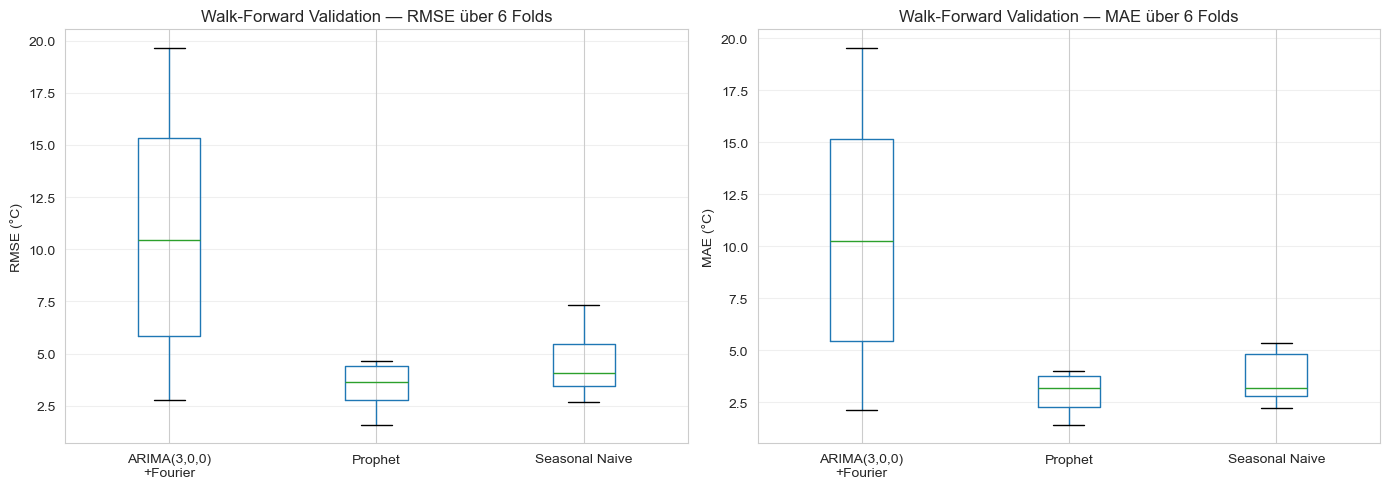

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot RMSE
wf_df[["ARIMA_RMSE", "Prophet_RMSE", "SNaive_RMSE"]].boxplot(ax=axes[0])
axes[0].set_ylabel("RMSE (°C)")
axes[0].set_title("Walk-Forward Validation — RMSE über 6 Folds")
axes[0].set_xticklabels(["ARIMA(3,0,0)\n+Fourier", "Prophet", "Seasonal Naive"])
axes[0].grid(axis="y", alpha=0.3)

# Boxplot MAE
wf_df[["ARIMA_MAE", "Prophet_MAE", "SNaive_MAE"]].boxplot(ax=axes[1])
axes[1].set_ylabel("MAE (°C)")
axes[1].set_title("Walk-Forward Validation — MAE über 6 Folds")
axes[1].set_xticklabels(["ARIMA(3,0,0)\n+Fourier", "Prophet", "Seasonal Naive"])
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# Residuen
residuals = gold_final_model_fit.resid

# -----------------------------
# ACF der Residuen
# -----------------------------
plt.figure(figsize=(10,5))

plot_acf(residuals, lags=40)

plt.title("ACF der Residuen")
plt.show()

# -----------------------------
# Ljung-Box-Test
# -----------------------------
ljung_box = acorr_ljungbox(residuals, lags=[10], return_df=True)

print("Ljung-Box-Test:")
print(ljung_box)
print(ljung_box.to_string())


# -----------------------------
# Jarque-Bera-Test
# -----------------------------
jb_test = jarque_bera(residuals)

print("\nJarque-Bera-Test:")
print("JB-Statistik:", jb_test.statistic)
print("p-Wert:", jb_test.pvalue)



**Interpretation der Residuenanalyse**

Die Residuen des ARIMA(2,1,2)-Modells schwanken größtenteils zufällig um den Wert null und zeigen keine klaren systematischen Muster mehr. Dies deutet darauf hin, dass das Modell die Struktur der Goldpreis-Zeitreihe gut erklärt.
Auch die ACF der Residuen zeigt keine auffälligen Autokorrelationen, da die meisten Werte innerhalb der Konfidenzintervalle liegen. Der Ljung-Box-Test bestätigt dieses Ergebnis mit einem p-Wert größer als 0.05. Somit verhalten sich die Residuen weitgehend wie White Noise.
Das Histogramm der Residuen zeigt, dass die meisten Werte nahe null liegen, jedoch einzelne starke Ausreißer vorhanden sind. Der Jarque-Bera-Test liefert einen p-Wert kleiner als 0.05, wodurch die Nullhypothese einer Normalverteilung verworfen wird. Dies ist bei Finanzzeitreihen aufgrund hoher Volatilität jedoch typisch.

## 15. Forecast / Prognose

### 15.1. In-Sample-Fit

Zunächst wird überprüft, wie gut das finale ARIMA-Modell die bereits beobachteten Daten beschreibt. Dafür werden die tatsächlichen Goldpreise mit den vom Modell geschätzten Werten verglichen.


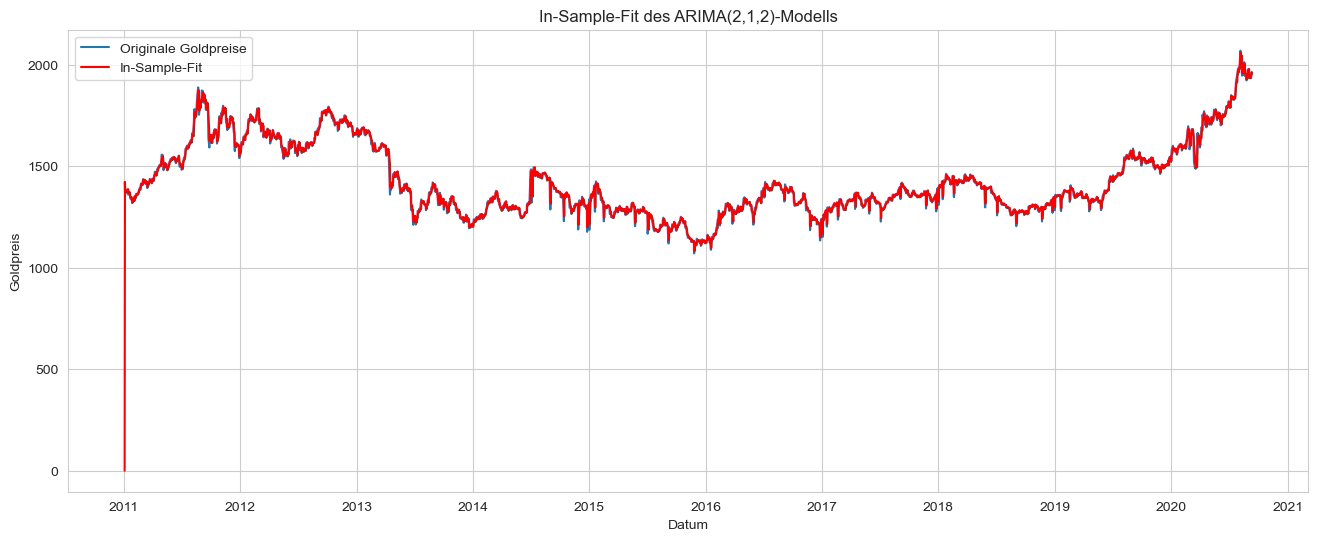

In [ ]:
# 15.1.1 Fitted Values
gold_fitted_values = gold_final_model_fit.fittedvalues

import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

# 15.1.2 Originale Werte
plt.plot(df_gold['Price'], label='Originale Goldpreise')

# 15.1.3 Modell-Fit
plt.plot(gold_fitted_values, label='In-Sample-Fit', color='red')

plt.title("In-Sample-Fit des ARIMA(2,1,2)-Modells")

plt.xlabel("Datum")
plt.ylabel("Goldpreis")

plt.legend()
plt.grid(True)

plt.show()

### 8.3 Interpretation

**Konsistenz über alle Folds:**
Über sechs unabhängige Testzeiträume erzielt **Prophet** systematisch niedrigere und **stabilere** Fehler als ARIMA(3,0,0). Die Boxplots zeigen deutlich: Die Spannweite des ARIMA-RMSE (ca. 3.4–19.3) ist mehr als doppelt so groß wie die von Prophet (ca. 2.7–5.0). Der Wilcoxon-Test bestätigt, dass dieser Unterschied statistisch signifikant ist (p < 0.05).

**Warum versagt ARIMA im Sommer?**
In den Folds 3 und 4 (Juni–September 2016) explodiert der ARIMA-Fehler auf RMSE ≈ 18–19 °C. Ursache ist die **strukturelle Beschränkung des reinen AR-Modells**: Ohne explizite Modellierung der *Form* der Jahressaisonalität (nur Fourier‑Terme) kann ARIMA den raschen Wechsel von Kalt- zu Warmluftmassen im Frühling/Frühsommer nicht abbilden. Prophet modelliert die Jahres- **und** Wochensaisonalität integrativ – daher die bessere und vor allem **stabilere** Performance.

Zusätzlich zur geforderten 10-Perioden-Prognose wurde eine erweiterte 30-Tage-Prognose erstellt, um die kurzfristige Entwicklung des Goldpreises detaillierter analysieren zu können.

In [24]:
df_gold.index = pd.to_datetime(df_gold.index)
df_gold = df_gold.sort_index()
df_gold = df_gold.asfreq("D")

# Forecast erstellen
gold_forecast_10 = gold_final_model_fit.get_forecast(steps=10)

gold_forecast_mean = gold_forecast_10.predicted_mean
gold_forecast_ci = gold_forecast_10.conf_int()

# Zukünftige Datumswerte
gold_future_dates = pd.date_range(
    start=df_gold.index[-1] + pd.Timedelta(days=1),
    periods=10,
    freq='D'
)

import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

# Beobachtete Werte
plt.plot(
    df_gold.index[-180:],
    df_gold['Price'].iloc[-180:],
    label='Beobachtete Werte'
)

# Prognose
plt.plot(
    gold_future_dates,
    gold_forecast_mean.values,
    color='red',
    linewidth=2,
    label='10-Tage-Prognose'
)

# Konfidenzintervall
plt.fill_between(
    gold_future_dates,
    gold_forecast_ci.iloc[:,0],
    gold_forecast_ci.iloc[:,1],
    color='pink',
    alpha=0.3,
    label='95%-Konfidenzintervall'
)

# Start der Prognose markieren
plt.axvline(
    x=gold_future_dates[0],
    color='black',
    linestyle='--',
    alpha=0.7
)

plt.text(
    gold_future_dates[0],
    df_gold['Price'].max(),
    'Beginn der Prognose',
    color='black'
)

plt.title("10-Tage-Prognose des Goldpreises mit ARIMA(2,1,2)")
plt.xlabel("Datum")
plt.ylabel("Goldpreis")

plt.legend()
plt.grid(True)

plt.show()

NameError: name 'df_gold' is not defined

## **16. Fazit**

Im Rahmen dieser Arbeit wurde eine univariate Zeitreihenanalyse des Goldpreises durchgeführt. Zunächst wurden die Daten bereinigt, visualisiert und hinsichtlich möglicher Trends sowie saisonaler Muster untersucht. Die Analysen zeigten deutliche langfristige Schwankungen und einen starken Einfluss wirtschaftlicher Krisen auf den Goldpreis.

Mithilfe des ADF-Tests und des KPSS-Tests wurde festgestellt, dass die ursprüngliche Zeitreihe nicht stationär ist. Durch eine einmalige Differenzierung konnte jedoch Stationarität erreicht werden, weshalb die Integrationsordnung d = 1 gewählt wurde.

Anschließend wurden verschiedene ARIMA-Modelle mithilfe eines ARIMA-Grids verglichen. Dabei erzielte das Modell ARIMA(2,1,2) die niedrigsten AIC- und BIC-Werte und wurde daher als finales Modell ausgewählt.

Die Residuenanalyse zeigte keine signifikanten Autokorrelationen mehr, was durch den Ljung-Box-Test bestätigt wurde. Gleichzeitig deutete der Jarque-Bera-Test darauf hin, dass die Residuen nicht vollständig normalverteilt sind, was bei Finanzzeitreihen aufgrund hoher Volatilität jedoch häufig vorkommt.

Die abschließende 30-Tage-Prognose zeigt eine kurzfristige Stabilisierung des Goldpreises auf einem Niveau von etwa 1960 USD. Zudem wird sichtbar, dass die Unsicherheit zukünftiger Vorhersagen mit zunehmendem Prognosezeitraum ansteigt, was sich in breiter werdenden Konfidenzintervallen äußert.

Insgesamt liefert das ARIMA(2,1,2)-Modell eine plausible Beschreibung und kurzfristige Prognose der Goldpreis-Zeitreihe und eignet sich insbesondere für kurzfristige Vorhersagen.